# Operation Full Output Notebook

> **说明：本 notebook 主要用于保存和展示一次完整运行后的输出结果。**
>
> 该文件是结果归档文件，不建议直接重新运行全部单元格，否则可能覆盖当前保存的输出结果。
>
> 如需复现实验流程，请优先运行 `run_final_report.py`，并查看 `reports/final_*` 结果文件。
>
> 如需查看完整研究/调参流程，请参考 `operation.py` 或 `operation.ipynb`。


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
""" 导入库 """
from pipeline import *
from visualization import *
import matplotlib.pyplot as plt
from IPython.display import display
import warnings

""" 数据处理以外的准备工作 """
warnings.filterwarnings('ignore') # 忽略警告信息
plt.rcParams['font.sans-serif'] = ['SimHei'] # 设置中文显示
plt.rcParams['axes.unicode_minus'] = False

# 更好地打印数据框的辅助函数
def print_df(df: pd.DataFrame, precision: int=4, is_index_hidden: bool=True):
    df_print = df.copy()
    
    def smart_float_format(x: float, epsilon: float=1e-10) -> str:
        for n in range(precision):
            if abs(x - round(x, n)) < epsilon:
                return str(round(x, n))
        return str(round(x, precision))
    
    def smart_p_format(x: float) -> str:
        if x < 0.001:
            return f'<0.001***'
        elif x < 0.01:
            return f'{x}**'
        elif x < 0.05:
            return f'{x}*'
        else:
            return f'{x}'
    
    # 对p值一列添加显著性提示符号
    p_value_cols = [col for col in df_print.columns if 'p_value' in col or 'p value' in col]
    for col in p_value_cols:
        df_print[col] = df_print[col].map(smart_p_format)
    
    # 找出所有可以安全转换为数值类型的列
    float_cols = []
    for col in df_print.columns:
        # 尝试转换为数值，如果成功且是浮点类型，则加入列表
        try:
            converted = pd.to_numeric(df_print[col], errors='raise')
            if pd.api.types.is_float_dtype(converted):
                float_cols.append(col)
                df_print[col] = converted
        except (ValueError, TypeError):
            continue
    
    # 只对浮点数列进行格式化
    float_cols = df_print.select_dtypes(include=['float']).columns
    for col in float_cols:
        df_print[col] = df_print[col].map(smart_float_format)
    if is_index_hidden:
        display(df_print.style.hide(axis='index'))
    else:
        display(df_print)


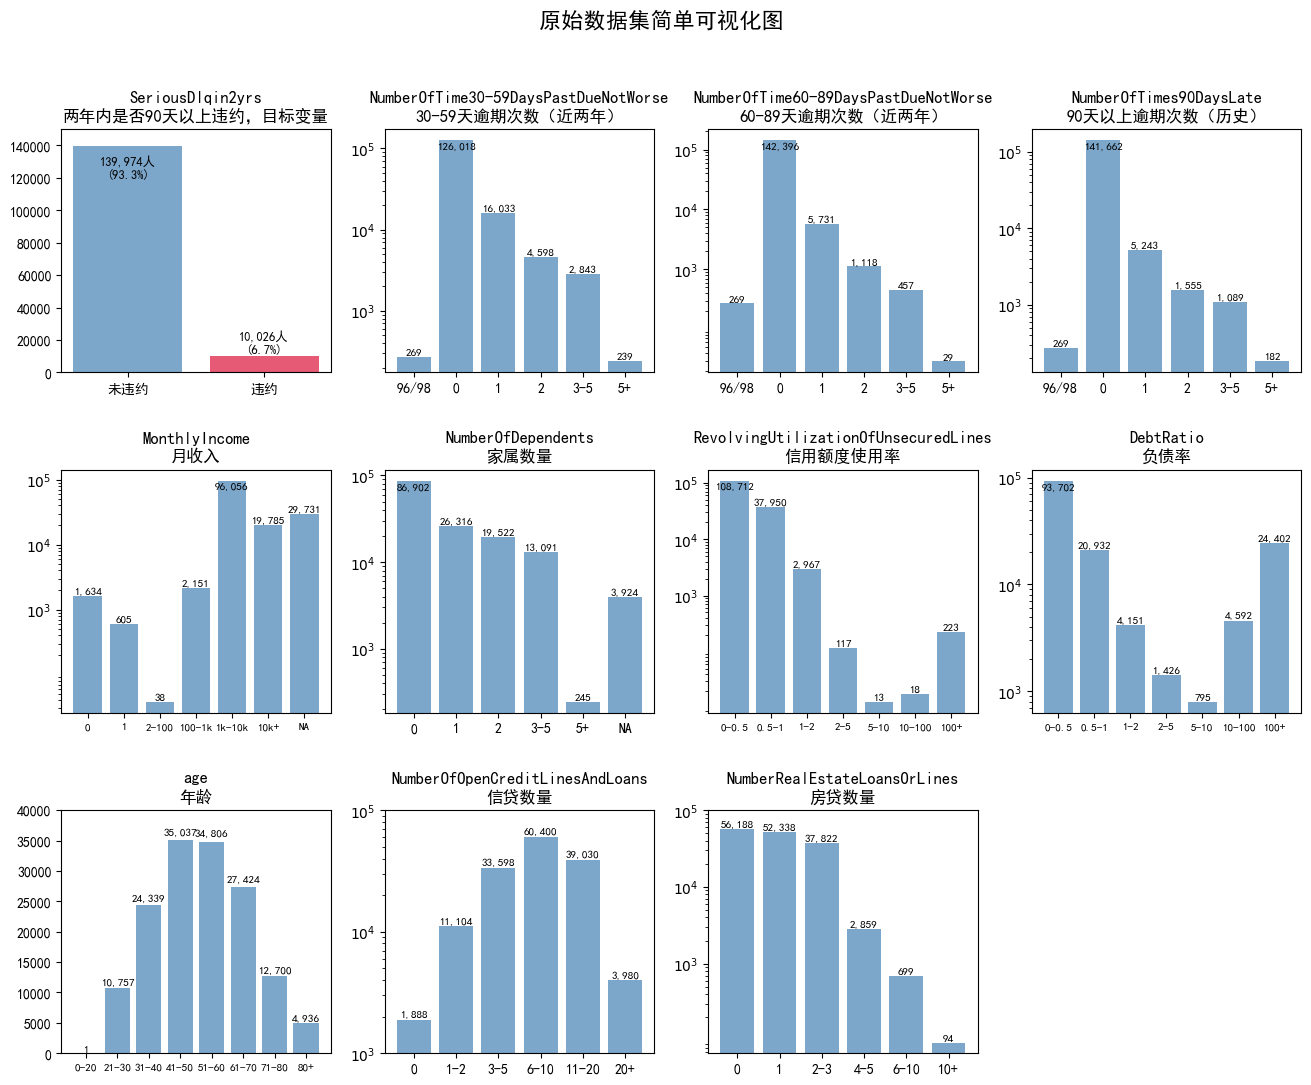

In [3]:
""" 初步探索数据 """
# 加载原始数据
origin_data = import_data(filetype='train')
# 基础可视化
fig = show_basic_visualization(origin_data)

In [4]:
plt.close(fig)

In [5]:
# 补充的重要发现
special_discovery_df = show_special_discovery(origin_data)
print_df(special_discovery_df)

相关列,重要发现,由此推出的结论
月收入与家属数,只有这两列存在缺失值，其他列无缺失,后续只需处理这两列的缺失值
家属数→月收入,家庭成员缺失共3924人，其中月收入也缺失3924人（True）,家庭成员缺失的人，月收入必然缺失
月收入→家属数,月收入缺失共29731人，其中家庭成员也缺失3924人,月收入缺失时，家庭成员不一定缺失（存在仅月收入缺失的样本）
三个逾期次数指标,96/98编码完全对应同一批人，共269人,96/98不具有业务意义，是银行赋予的特殊标记
房贷数与信贷数,同一个样本的信贷数不会低于房贷数,房贷是信贷的其中一种


In [6]:
""" 初步数据清洗，针对客观事实，允许在全局数据集进行 """
# 缺失值相关标记
completeness_desc_df, completeness_test_df = add_missing_flag(origin_data)
print_df(completeness_desc_df, precision=2)

组别,人数,平均年龄,平均信贷数,平均房贷数,平均违约率(%)
完整组,120269,51.29,8.76,1.05,6.95
单缺组,25807,55.87,7.46,0.91,5.77
全缺组,3924,59.59,5.6,0.59,4.56


In [7]:
print_df(completeness_test_df)

变量,检验方法,统计量,p 值,效应值名称,效应量,效应解释
违约情况,卡方检验,76.13,<0.001***,Cramer's V,0.0225,可忽略
年龄,单因素方差分析,1540.0,<0.001***,Cohen's f,0.1435,小效应
信贷数,Kruskal-Wallis H 检验,3190.0,<0.001***,Epsilon2,0.0213,小效应
房贷数,Kruskal-Wallis H 检验,1210.0,<0.001***,Epsilon2,0.008,可忽略


In [8]:
# 逾期次数 96/98 相关标记
blacklist_desc_df, blacklist_test_df = add_blacklist_flag(origin_data)
print_df(blacklist_desc_df, precision=2)

组别,人数,平均年龄,平均信贷数,平均房贷数,平均违约率(%)
有编码组,269,34.25,0.01,0.0,54.65
无编码组,149731,52.33,8.47,1.02,6.6


In [9]:
print_df(blacklist_test_df)

变量,检验方法,统计量,p 值,效应值名称,效应量,效应解释
违约情况,卡方检验,986.0,<0.001***,Odds Ratio,17.0574,极大效应
年龄,Welch's t 检验,-22.68,<0.001***,Cohen's d,-1.2977,大效应
信贷数,Mann-Whitney U 检验,224000.0,<0.001***,Cliff's delta,-0.9889,大效应
房贷数,Mann-Whitney U 检验,7520000.0,<0.001***,Cliff's delta,-0.6265,大效应


In [10]:
# 月收入异常（极低，0-10）相关标记
zero_vs_low_desc_df, zero_vs_low_test_df, abnormal_vs_normal_desc_df, abnormal_vs_normal_test_df = \
    add_income_anomaly_flag(origin_data)
print_df(zero_vs_low_desc_df, precision=2)

组别,人数,平均年龄,平均信贷数,平均房贷数,平均违约率(%)
月收入0组,1634,48.34,7.06,0.72,4.04
月收入1-10组,619,45.98,7.45,0.81,2.91


In [11]:
print_df(zero_vs_low_test_df)

变量,检验方法,统计量,p 值,效应值名称,效应量,效应解释
违约情况,卡方检验,1.3,0.2540,Odds Ratio,1.4054,可忽略
年龄,Welch's t 检验,3.29,0.0010**,Cohen's d,0.1505,小效应
信贷数,Mann-Whitney U 检验,480000.0,0.0649,Cliff's delta,-0.0502,可忽略
房贷数,Mann-Whitney U 检验,475000.0,0.0162*,Cliff's delta,-0.0602,可忽略


In [12]:
print_df(abnormal_vs_normal_desc_df, precision=2)

组别,人数,平均年龄,平均信贷数,平均房贷数,平均违约率(%)
"月收入异常[0, 10]组",2253,47.69,7.17,0.74,3.73
其余月收入（无NA）组,118016,51.36,8.79,1.06,7.01


In [13]:
print_df(abnormal_vs_normal_test_df)

变量,检验方法,统计量,p 值,效应值名称,效应量,效应解释
违约情况,卡方检验,36.32,<0.001***,Odds Ratio,0.5137,小效应
年龄,Welch's t 检验,-10.69,<0.001***,Cohen's d,-0.2398,中效应
信贷数,Mann-Whitney U 检验,107000000.0,<0.001***,Cliff's delta,-0.1971,小效应
房贷数,Mann-Whitney U 检验,111000000.0,<0.001***,Cliff's delta,-0.1674,小效应


In [14]:
""" 分离测试集 """
# region
random_seed = 50
train_valid_data, test_data = train_test_split(
    origin_data,
    test_size=0.2, 
    random_state=random_seed,
    stratify=origin_data[target]
)
train_valid_data_copy = train_valid_data.copy(); test_data_copy = test_data.copy() # 备份
# endregion

In [15]:
""" 筛选值得添加交互标记的交互项 """
is_processing_here1 = True

if is_processing_here1:
    # region
    valuable_intersections_df_list = []
    # 划分训练集、验证集，准备K=5折交叉验证
    random_seed = 100
    folds = create_kfold(train_valid_data, random_seed, n_splits=5)
    for fold_idx in range(len(folds)):
        # 训练集、验证集拆分
        train_idx_list, _ = folds[fold_idx]
        train_data = train_valid_data.iloc[train_idx_list].copy()
        # endregion
        
        """ 统一数据清洗阶段 """
        # region
        silently = False if fold_idx == 0 else True
        # 截断家属数异常大值
        cap_dep_num(train_data, silently=silently)
        # 删除年龄异常小值
        delete_small_age(train_data, silently=silently)
        # 添加信用额度使用率的若干标记
        add_util_flags(train_data, silently=silently)
        # 添加负债率的若干标记
        add_debt_flags(train_data, silently=silently)
        # 添加三种逾期次数的加权求和，权重由逻辑回归模型训练
        beta30, beta60, beta90 = add_late_severity_score(train_data)
        # 添加衍生指标
        add_derived_features(train_data)
        # 整理指标顺序
        train_data = reorder_columns(train_data)
        # endregion
        
        """ 构建全部的一维分箱、二维分箱，计算每个交互项的评判指标 """
        # region
        # 筛选出所有非二元指标
        colnames_not_binary = get_colnames_whether_binary(train_data, is_binary=False)
        # 对所有非布尔值类型的指标建立一维分箱
        for colname in colnames_not_binary:
            _, div_pts = add_bins_1D(train_data, colname)
        # 把一维分箱的具体数值转换为排名序号
        convert_bins_value_to_rank(train_data)
        # 列出通过筛选的一维分箱对应指标的所有无序对
        colname_pairs_not_binary = []
        for i in range(len(colnames_not_binary) - 1):
                for j in range(i + 1, len(colnames_not_binary)):
                    colname_pairs_not_binary.append([colnames_not_binary[i], colnames_not_binary[j]])
        # 对两两配对的每对指标建立二维分箱
        for colname_pair in colname_pairs_not_binary:
            _, bins_2D = add_bins_2D(train_data, colname_pair)
        # 找出有价值添加交互标记的二维分箱
        valuable_intersections_df = find_valuable_intersections(train_data, colname_pairs_not_binary)
        valuable_intersections_df_list.append(valuable_intersections_df)
        # endregion

NumberOfDependents大于10的样本数为1，已删除
Age小于18的样本数为1，已删除
RevolvingUtilizationOfUnsecuredLines处于0.75-1的样本数有15437，占比16.08%，违约率18.28%
RevolvingUtilizationOfUnsecuredLines处于1-5的样本数有1942，占比2.02%，违约率40.37%
RevolvingUtilizationOfUnsecuredLines处于5以上的样本数有165，占比0.17%，违约率8.48%
月收入可靠的样本数为75417，占比78.56%
月收入可靠的样本中，DebtRatio处于0.75-1的样本数有3353，占比4.45%，违约率11.18%
月收入可靠的样本中，DebtRatio处于1-5的样本数有3137，占比4.16%，违约率13.71%
月收入可靠的样本中，DebtRatio处于5以上有205，占比0.27%，违约率7.8%


In [16]:
# 筛选交互效应为增强的排名前30的二维分箱与交互效应为削弱的排名前10的二维分箱，再做人工复查：删除或合并
if is_processing_here1: # 只在最后一折时做
    top_positive_intersections_df, top_negative_intersections_df = \
        filter_intersections(valuable_intersections_df_list)
    print_df(top_positive_intersections_df)

binname_2D,bin1_1D,bin2_1D,LIFT_mean,corrected_LIFT_mean,ASR_mean,intersection_Z_score_mean,mark
late_severity_score_x_short_late_bin,2,1,4.2638,3.2334,80.1372,24.3277,23.8104
credit_late_density_x_late_severity_score_bin,1,2,3.7253,3.3936,71.4466,25.4601,22.2071
30-59late_x_short_late_bin,1,2,4.7788,2.2715,114.6256,18.5459,17.7695
late_severity_score_x_30-59late_bin,2,1,4.0728,2.2552,119.1423,21.6284,16.7819
age_x_late_severity_score_bin,6,4,6.7486,2.6309,24.8951,11.025,14.2508
credit_late_density_x_late_severity_score_bin,1,4,6.8878,1.7774,91.481,10.4991,11.7862
late_severity_score_x_util_bin,4,2,5.4597,3.0583,14.7351,8.4604,10.9003
credit_pressure_index_x_debt_bin,3,1,2.2937,3.8275,19.1431,26.4715,10.7759
late_severity_score_x_util_bin,4,1,5.4204,2.5902,18.9245,9.2742,10.535
credit_late_density_x_30-59late_bin,5,1,6.2682,1.781,70.3357,7.1636,8.872


In [17]:
if is_processing_here1:
    print_df(top_negative_intersections_df)

binname_2D,bin1_1D,bin2_1D,LIFT_mean,corrected_LIFT_mean,ASR_mean,intersection_Z_score_mean,mark
credit_x_util_bin,1,2,0.1496,0.3814,-11.799,-4.4999,6.7965
monthly_debt_x_mortgage_bin,1,2,0.2177,0.272,-6.389,-4.0067,5.1102
debt_x_monthly_debt_bin,2,4,0.2857,0.3742,-9.6805,-6.0931,5.0507
credit_pressure_index_x_mortgage_bin,2,2,0.1789,0.574,-22.5493,-4.88,4.719
monthly_debt_x_util_bin,1,2,0.1338,0.5509,-16.5686,-3.505,4.2223
credit_pressure_index_x_debt_bin,2,2,0.1895,0.5685,-18.4695,-4.5981,4.1792
credit_pressure_index_x_monthly_debt_bin,3,4,0.304,0.4937,-13.5895,-6.3463,4.0522
credit_x_util_bin,1,3,0.2915,0.4126,-9.1023,-5.3599,4.0462
credit_pressure_index_x_monthly_debt_bin,2,3,0.1863,0.5533,-16.1564,-4.1662,3.9496
age_x_monthly_debt_bin,6,1,0.1975,0.5642,-16.3917,-4.4449,3.8729


In [18]:
""" 列出值得添加的交互标记 """
# region
# 增强效应交互项
positive_interactions_df = pd.DataFrame({
    # 交互标记名称
    'signal_name': [
        # 参与交互的两个一维分箱都是只与逾期次数相关的，后续记为第一组
        'late_severity_mid_x_short_late_low_signal',
        'late_severity_high_x_short_late_low_signal',
        '30-59late_low_x_short_late_mid_high_signal',
        '90+late_mid_high_x_short_late_low_signal',
        # 参与交互的两个一维分箱一个只与逾期次数相关，另一个也涉及逾期次数，后续记为第二组
        '30-59late_low_x_credit_late_density_mid_high_signal',
        'age_high_x_credit_late_density_high_signal',
        'util_low_x_credit_late_density_high_signal',
        'mortgage_ratio_mid_x_credit_late_density_high_signal',
        'mortgage_mid_x_credit_late_density_high_signal',
        # 参与交互的两个一维分箱有且只有一个与逾期次数相关，后续记为第三组
        'dep_missing_x_60-89late_mid_signal',
        'age_high_x_late_severity_high_signal',
        'age_high_x_90+late_mid_signal',
        'util_low_mid_x_late_severity_high_signal',
        'util_mid_x_90+late_mid_signal',
        'age_high_x_60-89late_mid_signal',
        '30-59late_mid_x_credit_mid_signal',
        # 参与交互的两个一维分箱都不与逾期次数相关，后续记为第四组
        'debt_low_x_credit_pressure_mid_signal',
        'debt_mid_x_credit_pressure_high_signal',
        'util_high_x_credit_pressure_low_signal',
        'monthly_debt_low_x_credit_pressure_high_signal',
        'late_severity_high_x_credit_pressure_low_signal'
    ],
    # 参与交互的第一个一维分箱排名序号列名
    'binrank_colname1': [
        # 第一组
        'late_severity_score_binrank', 'late_severity_score_binrank', '30-59late_binrank',
        '90+late_binrank',
        # 第二组
        '30-59late_binrank', 'age_binrank', 'util_binrank',
        'mortgage_ratio_binrank', 'mortgage_binrank',
        # 第三组
        'dep_binrank', 'age_binrank', 'age_binrank', 
        'util_binrank', 'util_binrank', 'age_binrank', '30-59late_binrank',
        # 第四组
        'debt_binrank', 'debt_binrank',
        'util_binrank', 'monthly_debt_binrank',
        'late_severity_score_binrank'
    ],
    # 参与交互的第二个一维分箱排名序号列名
    'binrank_colname2': [
        # 第一组
        'short_late_binrank', 'short_late_binrank', 'short_late_binrank',
        'short_late_binrank',
        # 第二组
        'credit_late_density_binrank', 'credit_late_density_binrank', 'credit_late_density_binrank',
        'credit_late_density_binrank', 'credit_late_density_binrank',
        # 第三组
        '60-89late_binrank', 'late_severity_score_binrank', '90+late_binrank', 
        'late_severity_score_binrank','90+late_binrank', '60-89late_binrank', 'credit_binrank',
        # 第四组
        'credit_pressure_index_binrank', 'credit_pressure_index_binrank', 
        'credit_pressure_index_binrank', 'credit_pressure_index_binrank', 
        'credit_pressure_index_binrank'
    ],
    # 参与交互的第一个一维分箱的排名序号跨度
    'binrank1': [
        # 第一组
        '2_2', '4_4', '1_1',
        '3_4',
        # 第二组
        '1_1', '5_6', '1_1',
        '2_2', '2_2',
        # 第三组
        '-1_-1', '6_6', '6_6', 
        '1_2', '2_2', '6_6', '3_3',
        # 第四组
        '1_1', '2_2', 
        '5_5', '1_1',
        '4_4'
    ],
    # 参与交互的第二个一维分箱的排名序号跨度
    'binrank2': [
        # 第一组
        '1_1', '1_1', '2_4',
        '1_1',
        # 第二组
        '4_6', '6_6', '6_6',
        '6_6', '6_6',
        # 第三组
        '2_2', '4_4', '2_3', 
        '4_4', '2_2', '2_2', '2_2',
        # 第四组
        '3_4', '4_5',
        '1_2', '3_4',
        '1_2'
    ]
})# 削弱效应交互项
# 削弱效应交互项
negative_interactions_df = pd.DataFrame({
    # 交互标记名称
    'signal_name': [
        'credit_low_x_util_mid_signal',
        'monthly_debt_low_x_mortgage_ratio_mid_signal',
        'credit_pressure_mid_x_debt_mid_signal',
        'monthly_debt_high_x_debt_mid_signal',
        'credit_pressure_mid_x_mortgage_mid_signal',
        'monthly_debt_low_x_mortgage_mid_signal',
        'monthly_debt_low_x_age_high_signal',
        'monthly_debt_high_x_credit_pressure_mid_high_signal',
        'monthly_debt_mid_x_credit_pressure_mid_signal',
        'age_high_x_debt_low_signal'
    ],
    # 参与交互的第一个一维分箱排名序号列名
    'binrank_colname1': [
        'credit_binrank', 'monthly_debt_binrank', 'credit_pressure_index_binrank',
        'monthly_debt_binrank', 'credit_pressure_index_binrank', 'monthly_debt_binrank',
        'monthly_debt_binrank', 'monthly_debt_binrank', 'monthly_debt_binrank', 'age_binrank'
    ],
    # 参与交互的第二个一维分箱排名序号列名
    'binrank_colname2': [
        'util_binrank', 'mortgage_ratio_binrank', 'debt_binrank',
        'debt_binrank', 'mortgage_binrank', 'mortgage_binrank',
        'age_binrank', 'credit_pressure_index_binrank', 'credit_pressure_index_binrank', 'debt_binrank'
    ],
    # 参与交互的第一个一维分箱的排名序号跨度
    'binrank1': [
        '1_1', '1_1', '2_2',
        '4_4', '2_2', '1_1',
        '1_1', '4_4', '3_3', '6_6'
    ],
    # 参与交互的第二个一维分箱的排名序号跨度
    'binrank2': [
        '2_2', '2_2', '2_2',
        '2_2', '2_2', '2_2',
        '6_6', '3_3', '2_2', '1_1'
    ]
})
# 释放内存
if 'train_data' in dir():
    del train_data
# endregion

In [19]:
""" 筛选值得保留的标记、一维分箱与二维分箱 """
is_processing_here2 = True

if is_processing_here2:
# region
    binary_columns_test_df_list = []; bins_1D_test_df_list = []; bins_2D_test_df_list = []
    # 划分训练集、验证集，准备K=5折交叉验证
    random_seed = 1000
    folds = create_kfold(train_valid_data, random_seed, n_splits=5)
    for fold_idx in range(len(folds)):
        # 训练集、验证集拆分
        train_idx_list, valid_idx_list = folds[fold_idx]
        train_data = train_valid_data.iloc[train_idx_list].copy()
        valid_data = train_valid_data.iloc[valid_idx_list].copy()
        # endregion
        
        """ 统一数据清洗阶段 """
        # region
        # 截断家属数异常大值
        cap_dep_num(train_data); cap_dep_num(valid_data)
        # 删除年龄异常小值
        delete_small_age(train_data); delete_small_age(valid_data)
        # 添加信用额度使用率的若干标记
        add_util_flags(train_data); add_util_flags(valid_data)
        # 添加负债率的若干标记
        add_debt_flags(train_data); add_debt_flags(valid_data)
        # 添加三种逾期次数的加权求和，权重由逻辑回归模型训练
        beta30, beta60, beta90 = add_late_severity_score(train_data)
        add_late_severity_score(valid_data, [beta30, beta60, beta90])
        # 添加衍生指标
        add_derived_features(train_data); add_derived_features(valid_data)
        # 筛选出所有非二元指标
        colnames_not_binary = get_colnames_whether_binary(train_data, is_binary=False)
        # 对所有非布尔值类型的指标建立一维分箱
        for colname in colnames_not_binary:
            _, div_pts = add_bins_1D(train_data, colname)
            add_bins_1D(valid_data, colname, fixed_div_pts=div_pts)
        # 把一维分箱的具体数值转换为排名序号
        convert_bins_value_to_rank(train_data); convert_bins_value_to_rank(valid_data)
        # 添加交互标记
        add_intersection_signals(train_data, positive_interactions_df, negative_interactions_df)
        add_intersection_signals(valid_data, positive_interactions_df, negative_interactions_df)
        # 整理指标顺序
        train_data = reorder_columns(train_data); valid_data = reorder_columns(valid_data)
        # endregion
        
        """ 整理标记、一维分箱、二维分箱的评判指标 """
        # region
        # 找出所有二元列
        colnames_binary = get_colnames_whether_binary(train_data, is_binary=True)
        # 计算二元列的风险比率、IV
        binary_columns_test_df = test_binary_columns(train_data, colnames_binary)
        binary_columns_test_df_list.append(binary_columns_test_df)
        # 计算一维分箱的WOE、IV和PSI，做第一轮筛选
        bins_1D_test_df, iv_1D_dict = test_bins_1D(train_data, valid_data, colnames_not_binary)
        bins_1D_test_df_list.append(bins_1D_test_df)
        # 列出所有一维分箱对应指标的所有无序对
        colname_pairs_not_binary = []
        for i in range(len(colnames_not_binary) - 1):
                for j in range(i + 1, len(colnames_not_binary)):
                    colname_pairs_not_binary.append([colnames_not_binary[i], colnames_not_binary[j]])
        # 对两两配对的每对指标建立二维分箱
        for colname_pair in colname_pairs_not_binary:
            _, bins_2D = add_bins_2D(train_data, colname_pair)
            add_bins_2D(valid_data, colname_pair, fixed_bins_2D=bins_2D)
        # 计算二维分箱的WOE、IV、IV增量、IS、PSI，做第二轮筛选
        bins_2D_test_df = test_bins_2D(train_data, valid_data, colname_pairs_not_binary, iv_1D_dict)
        bins_2D_test_df_list.append(bins_2D_test_df)
        # endregion

In [20]:
# 展示统一数据清洗完毕时的全体指标名称（不含只起到过渡作用的分箱相关变量）
if is_processing_here2:
    colname_general_df = display_current_colnames_general(origin_data, train_data)
    print_df(colname_general_df)

原始指标,数据质量标记,衍生指标,用户行为标记,交互标记
SeriousDlqin2yrs（目标变量）,blacklist_flag,credit_late_density,has_no_credit,30-59late_low_x_credit_late_density_mid_high_signal
Age,both_missing_flag,credit_pressure_index,has_serious_late,30-59late_low_x_short_late_mid_high_signal
DebtRatio,debt_anomaly_flag,free_cashflow_income,has_short_late,30-59late_mid_x_credit_mid_signal
MonthlyIncome,income_anomaly_flag,income_per_dep,has_short_late_but_no_credit,90+late_mid_high_x_short_late_low_signal
NumberOfDependents,single_missing_flag,late_severity_score,is_debt_high,age_high_x_60-89late_mid_signal
NumberOfOpenCreditLinesAndLoans,util_anomaly_flag,monthly_debt,is_debt_overlimit,age_high_x_90+late_mid_signal
NumberOfTime30-59DaysPastDueNotWorse,,mortgage_ratio,is_util_high,age_high_x_credit_late_density_high_signal
NumberOfTime60-89DaysPastDueNotWorse,,short_late,is_util_overlimit,age_high_x_debt_low_signal
NumberOfTimes90DaysLate,,,,age_high_x_late_severity_high_signal
NumberRealEstateLoansOrLines,,,,credit_low_x_util_mid_signal


In [21]:
# 筛选出可以投入训练的标记、一维分箱、二维分箱
if is_processing_here2:
    binary_columns_filter_df = filter_binary_columns(binary_columns_test_df_list)
    bins_1D_filter_df = filter_bins_1D(bins_1D_test_df_list)
    passed_bins_2D_df = filter_bins_2D(bins_2D_test_df_list)
    print_df(binary_columns_filter_df)

colname,count_marked_mean,count_normal_mean,RR_mean,IV_mean,is_passed
blacklist_flag,177.6,95820.8,8.4113,0.0415,True
both_missing_flag,2513.6,93484.8,0.7234,0.0026,False
debt_anomaly_flag,199.2,95799.2,1.0167,0.0001,False
income_anomaly_flag,1454.4,94544.0,0.5396,0.0049,True
single_missing_flag,16641.6,79356.8,0.8373,0.0049,False
util_anomaly_flag,162.4,95836.0,1.2519,0.0001,False
has_no_credit,1200.8,94797.6,3.9909,0.0617,True
has_serious_late,5184.8,90636.0,8.9432,0.8476,True
has_short_late,17222.4,78598.4,6.2186,0.8969,True
has_short_late_but_no_credit,119.2,95879.2,4.6431,0.0088,True


In [22]:
if is_processing_here2:
    print_df(bins_1D_filter_df)

binname_1D,IV_mean,PSI_upper,p_value_upper,is_passed
30-59late_bin,0.763,0.0005,<0.001***,True
60-89late_bin,0.6087,0.0005,<0.001***,True
90+late_bin,0.8858,0.0006,<0.001***,True
age_bin,0.2452,0.0003,<0.001***,True
credit_bin,0.0647,0.0006,<0.001***,True
credit_late_density_bin,1.0512,0.0008,<0.001***,True
credit_pressure_index_bin,0.4506,0.0006,<0.001***,True
debt_bin,0.0756,0.0007,<0.001***,True
dep_bin,0.0338,0.0006,<0.001***,False
free_cashflow_income_bin,0.1351,0.0012,<0.001***,True


In [23]:
if is_processing_here2:
    print_df(passed_bins_2D_df)

binname_2D,IV_mean,delta_IV_mean,IS_mean,PSI_upper,p_value_upper,RR_mean,RV_mean
credit_x_credit_pressure_index_bin,0.6221,0.1716,1.2073,0.0027,<0.001***,0.1955,0.0026
credit_x_monthly_debt_bin,0.1405,0.0758,1.5203,0.0022,<0.001***,0.1109,0.0006
debt_x_credit_bin,0.2131,0.1376,1.5194,0.0034,<0.001***,0.1332,0.0009
debt_x_credit_pressure_index_bin,0.6606,0.2101,1.2557,0.0022,<0.001***,0.3175,0.0028
debt_x_monthly_debt_bin,0.1378,0.0622,1.335,0.0025,<0.001***,0.1178,0.0005
debt_x_mortgage_bin,0.2406,0.165,1.7629,0.0019,<0.001***,0.1384,0.0009
debt_x_mortgage_ratio_bin,0.1774,0.1018,1.6716,0.0019,<0.001***,0.1021,0.0006
dep_x_credit_bin,0.1218,0.057,1.2355,0.0024,<0.001***,0.1776,0.0006
dep_x_mortgage_bin,0.1157,0.0548,1.2209,0.0013,<0.001***,0.1067,0.0005
income_x_monthly_debt_bin,0.1413,0.0618,1.3203,0.0019,<0.001***,0.1215,0.0005


In [24]:
""" 列出通过筛选的标记、一维分箱、二维分箱 """
# region
# 交互标记的相关数据表
interaction_signals_test_df = pd.DataFrame({
    'signal colname': [
        '30-59late_low_x_credit_late_density_mid_high_signal',
        '30-59late_low_x_short_late_mid_high_signal',
        '30-59late_mid_x_credit_mid_signal',
        '90+late_mid_high_x_short_late_low_signal',
        'age_high_x_60-89late_mid_signal',
        'age_high_x_90+late_mid_signal',
        'age_high_x_credit_late_density_high_signal',
        'age_high_x_debt_low_signal',
        'age_high_x_late_severity_high_signal',
        'credit_low_x_util_mid_signal',
        'credit_pressure_mid_x_debt_mid_signal',
        'credit_pressure_mid_x_mortgage_mid_signal',
        'debt_low_x_credit_pressure_mid_signal',
        'debt_mid_x_credit_pressure_high_signal',
        'dep_missing_x_60-89late_mid_signal',
        'late_severity_high_x_credit_pressure_low_signal',
        'late_severity_high_x_short_late_low_signal',
        'late_severity_mid_x_short_late_low_signal',
        'monthly_debt_high_x_credit_pressure_mid_high_signal',
        'monthly_debt_high_x_debt_mid_signal',
        'monthly_debt_low_x_age_high_signal',
        'monthly_debt_low_x_credit_pressure_high_signal',
        'monthly_debt_low_x_mortgage_mid_signal',
        'monthly_debt_low_x_mortgage_ratio_mid_signal',
        'monthly_debt_mid_x_credit_pressure_mid_signal',
        'mortgage_mid_x_credit_late_density_high_signal',
        'mortgage_ratio_mid_x_credit_late_density_high_signal',
        'util_high_x_credit_pressure_low_signal',
        'util_low_mid_x_late_severity_high_signal',
        'util_low_x_credit_late_density_high_signal',
        'util_mid_x_90+late_mid_signal'
    ],
    'count marked': [
        1594.4, 2559.4, 549.6, 670.4, 356.0, 366.4, 714.4, 5405.8, 278.4,
        2404.8, 5945.2, 7693.0, 3049.0, 5038.8, 67.2, 518.6, 670.4, 1865.6,
        4325.2, 2079.8, 5407.8, 3844.4, 699.6, 204.4, 4502.8, 1290.4, 332.0,
        1636.2, 408.0, 287.4, 232.0
    ],
    'count normal': [
        118403.2, 117438.2, 119448.0, 119327.2, 119641.6, 119631.2, 119283.2, 114591.8, 119719.2,
        117592.8, 114052.4, 112304.6, 116948.6, 114958.8, 119930.4, 119479.0, 119327.2, 118132.0,
        115672.4, 117917.8, 114589.8, 116153.2, 119298.0, 119793.2, 115494.8, 118707.2, 119665.6,
        118361.4, 119589.6, 119710.2, 119765.6
    ],
    'RR': [
        5.097823, 4.286049, 5.877717, 6.705545, 3.454014, 4.489173, 5.541378, 0.17482, 6.485335,
        0.120923, 0.186938, 0.177958, 2.58384, 2.624934, 6.257462, 5.650464, 6.705545, 3.675369,
        0.316487, 0.314162, 0.191971, 2.507337, 0.255186, 0.117621, 0.202404, 6.714629, 6.963397,
        3.080146, 5.38985, 4.051518, 3.303112
    ],
    'IV': [
        0.106663, 0.116951, 0.051023, 0.079228, 0.01106, 0.020132, 0.058689, 0.071377, 0.031728,
        0.041168, 0.074248, 0.099769, 0.043014, 0.070817, 0.007285, 0.044717, 0.079228, 0.063386,
        0.031333, 0.015315, 0.066196, 0.049119, 0.006663, 0.003679, 0.05276, 0.146641, 0.043129,
        0.03737, 0.03227, 0.012746, 0.006525
    ]
})
# 通过筛选的标记
passed_binary_colnames = [
    # 数据质量标记
    'blacklist_flag',
    # 用户行为标记
    'has_no_credit',
    'has_serious_late',
    'has_short_late',
    'has_short_late_but_no_credit',
    'is_debt_high',
    'is_debt_overlimit',
    'is_util_high',
    'is_util_overlimit',
    # 交互标记
    '30-59late_low_x_credit_late_density_mid_high_signal',
    '30-59late_low_x_short_late_mid_high_signal',
    '30-59late_mid_x_credit_mid_signal',
    '90+late_mid_high_x_short_late_low_signal',
    'age_high_x_60-89late_mid_signal',
    'age_high_x_90+late_mid_signal',
    'age_high_x_credit_late_density_high_signal',
    'age_high_x_debt_low_signal',
    'age_high_x_late_severity_high_signal',
    'credit_low_x_util_mid_signal',
    'credit_pressure_mid_x_debt_mid_signal',
    'credit_pressure_mid_x_mortgage_mid_signal',
    'debt_low_x_credit_pressure_mid_signal',
    'debt_mid_x_credit_pressure_high_signal',
    'dep_missing_x_60-89late_mid_signal',
    'late_severity_high_x_credit_pressure_low_signal',
    'late_severity_high_x_short_late_low_signal',
    'late_severity_mid_x_short_late_low_signal',
    'monthly_debt_high_x_credit_pressure_mid_high_signal',
    'monthly_debt_high_x_debt_mid_signal',
    'monthly_debt_low_x_age_high_signal',
    'monthly_debt_low_x_credit_pressure_high_signal',
    'monthly_debt_low_x_mortgage_mid_signal',
    'monthly_debt_low_x_mortgage_ratio_mid_signal',
    'monthly_debt_mid_x_credit_pressure_mid_signal',
    'mortgage_mid_x_credit_late_density_high_signal',
    'mortgage_ratio_mid_x_credit_late_density_high_signal',
    'util_high_x_credit_pressure_low_signal',
    'util_low_mid_x_late_severity_high_signal',
    'util_low_x_credit_late_density_high_signal',
    'util_mid_x_90+late_mid_signal'
]
# 通过筛选的一维分箱
passed_binnames_1D = [
    '30-59late_bin',
    '60-89late_bin',
    '90+late_bin',
    'age_bin',
    'credit_bin',
    'credit_late_density_bin',
    'credit_pressure_index_bin',
    'debt_bin',
    'free_cashflow_income_bin',
    'income_bin',
    'income_per_dep_bin',
    'late_severity_score_bin',
    'mortgage_bin',
    'short_late_bin',
    'util_bin'
]
# 因IV低而未通过筛选的一维分箱
low_iv_binnames_1D = [
    'dep_bin', 'monthly_debt_bin', 'mortgage_ratio_bin'
]
# 通过筛选的二维分箱
passed_binnames_2D = [
    'credit_x_credit_pressure_index_bin',
    'credit_x_dep_bin',
    'credit_x_monthly_debt_bin',
    'debt_x_credit_bin',
    'debt_x_credit_pressure_index_bin',
    'debt_x_monthly_debt_bin',
    'debt_x_mortgage_bin',
    'debt_x_mortgage_ratio_bin',
    'income_x_monthly_debt_bin',
    'monthly_debt_x_credit_pressure_index_bin',
    'mortgage_x_credit_pressure_index_bin',
    'mortgage_x_dep_bin',
    'mortgage_x_monthly_debt_bin'
]
# 释放内存
if 'train_data' in dir() and 'valid_data' in dir():
    del train_data, valid_data
# endregion

In [25]:
""" 对raw LR模型的调试 """
is_processing_here3 = True

if is_processing_here3:
    # region
    raw_lr_fit_goodness_df_list = []
    # 划分训练集、验证集，准备K=5折交叉验证
    random_seed = 200
    folds = create_kfold(train_valid_data, random_seed, n_splits=5)
    for fold_idx in range(len(folds)):
        # 训练集、验证集拆分
        train_idx_list, valid_idx_list = folds[fold_idx]
        train_data = train_valid_data.iloc[train_idx_list].copy()
        valid_data = train_valid_data.iloc[valid_idx_list].copy()
        train_data_copy = train_data.copy(); valid_data_copy = valid_data.copy() # 备份
        # endregion
        
        """ 统一数据清洗阶段 """
        # region
        # 截断家属数异常大值
        cap_dep_num(train_data); cap_dep_num(valid_data)
        # 删除年龄异常小值
        delete_small_age(train_data); delete_small_age(valid_data)
        # 添加信用额度使用率的若干标记
        add_util_flags(train_data); add_util_flags(valid_data)
        # 添加负债率的若干标记
        add_debt_flags(train_data); add_debt_flags(valid_data)
        # 添加三种逾期次数的加权求和，权重由逻辑回归模型训练
        beta30, beta60, beta90 = add_late_severity_score(train_data)
        add_late_severity_score(valid_data, [beta30, beta60, beta90])
        # 添加衍生指标
        add_derived_features(train_data); add_derived_features(valid_data)
        # 筛选出所有非二元指标
        colnames_not_binary = get_colnames_whether_binary(train_data, is_binary=False)
        # 对所有非布尔值类型的指标建立一维分箱
        for colname in colnames_not_binary:
            _, div_pts = add_bins_1D(train_data, colname)
            add_bins_1D(valid_data, colname, fixed_div_pts=div_pts)
        # 把一维分箱的具体数值转换为排名序号
        convert_bins_value_to_rank(train_data); convert_bins_value_to_rank(valid_data)
        # 添加交互标记
        add_intersection_signals(train_data, positive_interactions_df, negative_interactions_df)
        add_intersection_signals(valid_data, positive_interactions_df, negative_interactions_df)
        # 暂时删除一维分箱列以及其对应的排名序号列
        colnames_without_bins = [colname for colname in train_data.columns if '_bin' not in colname]
        train_data = train_data[colnames_without_bins]; valid_data = valid_data[colnames_without_bins]
        # 整理指标顺序
        train_data = reorder_columns(train_data); valid_data = reorder_columns(valid_data)
        # endregion
        
        """ 对raw LR建立特化表达 """
        # region
        train_data_raw_lr = train_data.copy(); valid_data_raw_lr = valid_data.copy()
        # 缺失值、异常值全部赋值为0
        train_data_raw_lr = train_data_raw_lr.clip(lower=0)
        valid_data_raw_lr = valid_data_raw_lr.clip(lower=0)
        # 添加年龄、负债率、信用额度使用率的中心化三列以及中心化的年龄*负债率、年龄*信用额度使用率两列
        colnames_to_center = add_centered_features(train_data_raw_lr)
        add_centered_features(valid_data_raw_lr, fixed_colnames=colnames_to_center)
        # 对有长尾的指标取对数
        colnames_to_log = add_log_features(train_data_raw_lr)
        add_log_features(valid_data_raw_lr, fixed_colnames=colnames_to_log)
        # 筛选将要投入训练的列名
        selected_colnames = select_colnames_raw_lr(train_data_raw_lr)
        train_data_raw_lr = train_data_raw_lr[selected_colnames]
        valid_data_raw_lr = valid_data_raw_lr[selected_colnames]
        # endregion
        
        """ 训练raw LR """
        # region
        # 拆分目标变量和自变量
        y_train = train_data[target]; y_valid = valid_data[target]
        X_train_raw_lr = train_data_raw_lr.drop(target, axis=1, inplace=False)
        X_valid_raw_lr = valid_data_raw_lr.drop(target, axis=1, inplace=False)
        # 以下是可能尝试参与拟合的多种指标序列
        # 原始指标
        original_features = [
            'age_centered', 'util_centered', 'debt_centered',
            'income_log', dep, credit, mortgage,
            late30, late60, late90
        ]
        # 数据质量标记
        quality_flags = [
            'single_missing_flag', 'both_missing_flag', 'blacklist_flag',
            'income_anomaly_flag', 'debt_anomaly_flag', 'util_anomaly_flag'
        ]
        # 衍生指标
        derived_features = [
            'free_cashflow_income_log', 'income_per_dep_log', 'monthly_debt_log',
            'credit_pressure_index', 'mortgage_ratio', 'credit_late_density',
            'short_late', 'late_severity_score'
        ]
        # 用户行为标记
        risk_signals = [
            'has_no_credit', 'has_short_late_but_no_credit', 'has_serious_late', 'has_short_late',
            'is_debt_high', 'is_debt_overlimit', 'is_util_high', 'is_util_overlimit'
        ]
        # 削弱效应第1-5名
        negative_1_5 = [
            'monthly_debt_low_x_mortgage_ratio_mid_signal',
            'credit_low_x_util_mid_signal',
            'credit_pressure_mid_x_mortgage_mid_signal',
            'credit_pressure_mid_x_debt_mid_signal',
            'monthly_debt_low_x_age_high_signal'
        ]
        # 增强效应第1-5名
        positive_1_5 = [
            'mortgage_ratio_mid_x_credit_late_density_high_signal',
            'mortgage_mid_x_credit_late_density_high_signal',
            '90+late_mid_high_x_short_late_low_signal',
            'late_severity_high_x_short_late_low_signal',
            'age_high_x_late_severity_high_signal'
        ]
        # 增强效应第6-10名
        positive_6_10 = [
            'dep_missing_x_60-89late_mid_signal',
            '30-59late_mid_x_credit_mid_signal',
            'late_severity_high_x_credit_pressure_low_signal',
            'age_high_x_credit_late_density_high_signal',
            'util_low_mid_x_late_severity_high_signal'
        ]
        # 增强效应第11-15名
        positive_11_15 = [
            '30-59late_low_x_credit_late_density_mid_high_signal',
            '30-59late_low_x_short_late_mid_high_signal',
            'age_high_x_90+late_mid_signal',
            'util_low_x_credit_late_density_high_signal',
            'late_severity_mid_x_short_late_low_signal'
        ]
        # 以下是不同的进行拟合的指标组合
        colnames_to_fit0 = original_features + quality_flags
        colnames_to_fit1 = colnames_to_fit0 + derived_features + risk_signals
        colnames_to_fit2 = colnames_to_fit1 + positive_1_5
        colnames_to_fit3 = colnames_to_fit1 + negative_1_5
        colnames_to_fit4 = colnames_to_fit2 + positive_6_10
        colnames_to_fit5 = colnames_to_fit4 + positive_11_15
        colnames_to_fit_list = [
            colnames_to_fit0, colnames_to_fit1, colnames_to_fit2,
            colnames_to_fit3, colnames_to_fit4, colnames_to_fit5
        ]
        # 正则化强度的倒数（参数C）的尝试列表
        c_list = [0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1, 2]
        # 构建raw LR拟合效果的数据表
        raw_lr_fit_goodness_df = grid_search_lr\
            (X_train_raw_lr, y_train, X_valid_raw_lr, y_valid, colnames_to_fit_list, c_list)
        raw_lr_fit_goodness_df_list.append(raw_lr_fit_goodness_df)
        # 确定最佳的拟合指标序号与参数C
        colnames_to_fit = colnames_to_fit1
        X_train_raw_lr = X_train_raw_lr[colnames_to_fit]; X_valid_raw_lr = X_valid_raw_lr[colnames_to_fit]
        c = 1
        # 以下是尝试舍弃以改善VIF的指标序列
        colnames_to_drop0 = []
        colnames_to_drop1 = [late30, late60, 'income_log', 'free_cashflow_income_log']
        colnames_to_drop2 = colnames_to_drop1 + [late90]
        colnames_to_drop3 = colnames_to_drop1 + ['monthly_debt_log']
        colnames_to_drop4 = colnames_to_drop1 + [late90, 'monthly_debt_log']
        colnames_to_drop_list = [
            colnames_to_drop0, colnames_to_drop1, colnames_to_drop2, colnames_to_drop3, colnames_to_drop4
        ]
        # endregion


In [26]:
# 展示对raw LR建立特化表达完毕后的即将投入训练的列名
if is_processing_here3:
    colname_raw_lr_df = display_current_colnames_raw_lr(train_valid_data, train_data, train_data_raw_lr)
    print_df(colname_raw_lr_df)

raw LR中新增指标,raw LR中删去原始指标,raw LR中删去衍生指标
monthly_debt_log,DebtRatio,monthly_debt
debt_centered,MonthlyIncome,income_per_dep
util_centered,Age,free_cashflow_income
income_log,RevolvingUtilizationOfUnsecuredLines,
age_centered,,
income_per_dep_log,,
age_centered_*_debt_centered,,
free_cashflow_income_log,,
age_centered_*_util_centered,,


In [27]:
# 网格搜索找出最合适的拟合指标方案和正则化强度的倒数C
if is_processing_here3:
    raw_lr_auc_ks_df, raw_lr_coef_sign_stability_df = test_fit_goodness_lr(raw_lr_fit_goodness_df_list)
    print_df(raw_lr_auc_ks_df)

fit columns index,C value,valid_AUC_mean,AUC_gap_mean,valid_KS_mean,KS_gap_mean
5.0,2.0,0.8613,0.0006,0.5698,-0.0018
5.0,1.0,0.8613,0.0006,0.5701,-0.0021
5.0,0.5,0.8612,0.0006,0.5697,-0.002
5.0,0.2,0.8612,0.0005,0.569,-0.002
5.0,0.1,0.861,0.0005,0.5678,-0.0013
5.0,0.05,0.8607,0.0005,0.567,-0.0012
4.0,2.0,0.8604,0.0005,0.565,-0.0019
4.0,1.0,0.8604,0.0005,0.5652,-0.0021
4.0,0.5,0.8604,0.0005,0.5651,-0.0022
2.0,2.0,0.8603,0.0005,0.5657,-0.0021


In [28]:
if is_processing_here3:
    print_df(raw_lr_coef_sign_stability_df)

fit columns index,C value,colname,sign stabilty,std
0.0,0.01,both_missing_flag,-0.2,0.0177
1.0,0.01,income_per_dep_log,-0.2,0.0089
1.0,0.025,credit_late_density,0.2,0.0249
1.0,0.05,credit_late_density,-0.2,0.0277
1.0,0.1,credit_late_density,0.2,0.0416
1.0,0.2,is_debt_high,0.2,0.0515
1.0,0.2,credit_late_density,-0.2,0.0283
1.0,0.2,income_per_dep_log,-0.2,0.0278
1.0,0.5,is_debt_high,-0.2,0.0564
1.0,0.5,income_per_dep_log,-0.2,0.0192


In [29]:
# 构建不同舍弃指标方案的VIF测试结果表
if is_processing_here3:
    raw_lr_vif_test_df = test_vif_after_drop(X_train_raw_lr, colnames_to_drop_list)
    print_df(raw_lr_vif_test_df)

drop colnames index,VIF>20 count,10<VIF<=20 count,max VIF,max VIF colname
0,10,1,inf,NumberOfTime30-59DaysPastDueNotWorse
1,5,0,254.57,late_severity_score
2,2,0,39.9982,monthly_debt_log
3,3,0,245.7031,late_severity_score
4,0,2,11.1178,late_severity_score


In [30]:
""" 确定对于raw LR的最佳拟合指标与参数C """
# region
colnames_to_fit_raw_lr = [
        # 原始指标
        'age_centered', 'util_centered', 'debt_centered',
        'income_log', dep, credit, mortgage,
        late30, late60, late90,
        # 数据质量标记
        'single_missing_flag', 'both_missing_flag', 'blacklist_flag',
        'income_anomaly_flag', 'debt_anomaly_flag', 'util_anomaly_flag',
        # 衍生指标
        'free_cashflow_income_log', 'income_per_dep_log', 'monthly_debt_log',
        'credit_pressure_index', 'mortgage_ratio', 'credit_late_density',
        'short_late', 'late_severity_score',
        # 用户行为标记
        'has_no_credit', 'has_short_late_but_no_credit', 'has_serious_late', 'has_short_late',
        'is_debt_high', 'is_debt_overlimit', 'is_util_high', 'is_util_overlimit'
]
c_raw_lr = 1
colnames_to_drop_raw_lr = [
    late30, late60, late90, 
    'income_log', 'free_cashflow_income_log', 'monthly_debt_log'
]
# 检测固定最佳的删除指标后模型拟合效果的变化情况
if is_processing_here3:
    raw_lr_fit_goodness_after_drop_test_df = test_fit_goodness_lr_after_drop(
        X_train_raw_lr, y_train, X_valid_raw_lr, y_valid, 
        colnames_to_fit_raw_lr, c_raw_lr, colnames_to_drop_raw_lr
    )
    print_df(raw_lr_fit_goodness_after_drop_test_df)
# 简化变量
colnames_to_fit_raw_lr = \
    [colname for colname in colnames_to_fit_raw_lr if colname not in colnames_to_drop_raw_lr]
# 释放内存
if 'train_data_raw_lr' in dir() and 'valid_data_raw_lr' in dir():
    del train_data, valid_data, train_data_raw_lr, valid_data_raw_lr
# endregion


status,valid AUC,AUC gap,valid KS,KS gap
retained,0.8639,-0.0043,0.5763,-0.0139
dropped,0.8628,-0.0044,0.5754,-0.0162
difference,0.001,0.0001,0.001,0.0023


In [31]:
""" 对WOE LR模型的调试 """
is_processing_here4 = True

if is_processing_here4:
    # region
    woe_lr_fit_goodness_df_list = []
    # 划分训练集、验证集，准备K=5折交叉验证
    random_seed = 300
    folds = create_kfold(train_valid_data, random_seed, n_splits=5)
    for fold_idx in range(len(folds)):
        # 训练集、验证集拆分
        train_idx_list, valid_idx_list = folds[fold_idx]
        train_data = train_valid_data.iloc[train_idx_list].copy()
        valid_data = train_valid_data.iloc[valid_idx_list].copy()
        train_data_copy = train_data.copy(); valid_data_copy = valid_data.copy() # 备份
    # endregion
        
        """ 统一数据清洗阶段 """
        # region
        # 截断家属数异常大值
        cap_dep_num(train_data); cap_dep_num(valid_data)
        # 删除年龄异常小值
        delete_small_age(train_data); delete_small_age(valid_data)
        # 添加信用额度使用率的若干标记
        add_util_flags(train_data); add_util_flags(valid_data)
        # 添加负债率的若干标记
        add_debt_flags(train_data); add_debt_flags(valid_data)
        # 添加三种逾期次数的加权求和，权重由逻辑回归模型训练
        beta30, beta60, beta90 = add_late_severity_score(train_data)
        add_late_severity_score(valid_data, [beta30, beta60, beta90])
        # 添加衍生指标
        add_derived_features(train_data); add_derived_features(valid_data)
        # 筛选出所有非二元指标
        colnames_not_binary = get_colnames_whether_binary(train_data, is_binary=False)
        # 对所有非布尔值类型的指标建立一维分箱
        for colname in colnames_not_binary:
            _, div_pts = add_bins_1D(train_data, colname)
            add_bins_1D(valid_data, colname, fixed_div_pts=div_pts)
        # 把一维分箱的具体数值转换为排名序号
        convert_bins_value_to_rank(train_data); convert_bins_value_to_rank(valid_data)
        # 添加交互标记
        add_intersection_signals(train_data, positive_interactions_df, negative_interactions_df)
        add_intersection_signals(valid_data, positive_interactions_df, negative_interactions_df)
        # 暂时删除一维分箱列以及其对应的排名序号列
        colnames_without_bins = [colname for colname in train_data.columns if '_bin' not in colname]
        train_data = train_data[colnames_without_bins]; valid_data = valid_data[colnames_without_bins]
        # 整理指标顺序
        train_data = reorder_columns(train_data); valid_data = reorder_columns(valid_data)
        # endregion
        
        """ 对WOE LR建立特化表达 """
        # region
        train_data_woe_lr = train_data.copy(); valid_data_woe_lr = valid_data.copy()
        # 找出所有的非二元列
        colnames_not_binary = get_colnames_whether_binary(train_data_woe_lr, is_binary=False)
        # 对所有非布尔值类型的指标建立一维分箱（虽然构建了理应被淘汰的一维分箱，但后续控制其进入模型训练即可）
        for colname in colnames_not_binary:
            _, div_pts = add_bins_1D(train_data_woe_lr, colname)
            add_bins_1D(valid_data_woe_lr, colname, fixed_div_pts=div_pts)
        # 列出所有一维分箱对应指标的所有无序对
        colname_pairs_not_binary = []
        for i in range(len(colnames_not_binary) - 1):
                for j in range(i + 1, len(colnames_not_binary)):
                    colname_pairs_not_binary.append([colnames_not_binary[i], colnames_not_binary[j]])
        # 只建立通过筛选的二维分箱
        for colname_pair in colname_pairs_not_binary:
            _, bins_2D = add_bins_2D(train_data_woe_lr, colname_pair, constraint=passed_binnames_2D)
            add_bins_2D\
                (valid_data_woe_lr, colname_pair, fixed_bins_2D=bins_2D, constraint=passed_binnames_2D)
        # 把所有标记列、一维分箱列、二维分箱列转换为WOE列
        binnames_map_to_woe = \
            passed_binary_colnames + passed_binnames_1D + low_iv_binnames_1D + passed_binnames_2D
        for colname in binnames_map_to_woe:
            woe_map = fit_woe_mapping(train_data_woe_lr, colname)
            apply_woe_mapping(train_data_woe_lr, colname, woe_map)
            apply_woe_mapping(valid_data_woe_lr, colname, woe_map)
        # 在数据集中只留下投入训练的WOE列
        woe_colnames = [colname for colname in train_data_woe_lr.columns if colname.endswith('_woe')]
        train_data_woe_lr = train_data_woe_lr[[target] + woe_colnames]
        valid_data_woe_lr = valid_data_woe_lr[[target] + woe_colnames]
        # 重排指标列名
        train_data_woe_lr = reorder_columns(train_data_woe_lr)
        valid_data_woe_lr = reorder_columns(valid_data_woe_lr)
        # endregion
        
        """ 训练WOE LR """
        # region
        # 拆分目标变量和自变量
        y_train = train_data[target]; y_valid = valid_data[target]
        X_train_woe_lr = train_data_woe_lr.drop(target, axis=1, inplace=False)
        X_valid_woe_lr = valid_data_woe_lr.drop(target, axis=1, inplace=False)
        # 以下是可能尝试参与拟合的多种指标序列（已补充"_woe"后缀）
        # 原始指标
        original_features = [
            'age_bin_woe', 'util_bin_woe', 'debt_bin_woe',
            'income_bin_woe', 'credit_bin_woe', 'mortgage_bin_woe',
            '30-59late_bin_woe', '60-89late_bin_woe', '90+late_bin_woe'
        ]
        # 衍生指标
        derived_features = [
            'free_cashflow_income_bin_woe', 'income_per_dep_bin_woe',
            'credit_pressure_index_bin_woe', 'credit_late_density_bin_woe',
            'short_late_bin_woe', 'late_severity_score_bin_woe'
        ]
        # 含有较强风险信息的标记
        risk_signals = [
            'has_no_credit_woe', 'has_short_late_but_no_credit_woe', 
            'has_serious_late_woe', 'has_short_late_woe', 'blacklist_flag_woe',
            'is_debt_high_woe', 'is_debt_overlimit_woe', 
            'is_util_high_woe', 'is_util_overlimit_woe'
        ]
        # 二维分箱
        bins_2D = [
            'credit_x_credit_pressure_index_bin_woe',
            'credit_x_dep_bin_woe',
            'credit_x_monthly_debt_bin_woe',
            'debt_x_credit_bin_woe',
            'debt_x_credit_pressure_index_bin_woe',
            'debt_x_monthly_debt_bin_woe',
            'debt_x_mortgage_bin_woe',
            'debt_x_mortgage_ratio_bin_woe',
            'income_x_monthly_debt_bin_woe',
            'monthly_debt_x_credit_pressure_index_bin_woe',
            'mortgage_x_credit_pressure_index_bin_woe',
            'mortgage_x_dep_bin_woe',
            'mortgage_x_monthly_debt_bin_woe'
        ]
        # 低信息价值指标
        low_iv_features = [
            'dep_bin_woe', 'monthly_debt_bin_woe', 'mortgage_ratio_bin_woe'
        ]
        # 增强效应第1-5名
        positive_1_5 = [
            'mortgage_ratio_mid_x_credit_late_density_high_signal_woe',
            'mortgage_mid_x_credit_late_density_high_signal_woe',
            '90+late_mid_high_x_short_late_low_signal_woe',
            'late_severity_high_x_short_late_low_signal_woe',
            'age_high_x_late_severity_high_signal_woe'
        ]
        # 以下是不同的进行拟合的指标组合
        colnames_to_fit0 = original_features
        colnames_to_fit1 = colnames_to_fit0 + derived_features
        colnames_to_fit2 = colnames_to_fit1 + risk_signals
        colnames_to_fit3 = colnames_to_fit2 + bins_2D
        colnames_to_fit4 = colnames_to_fit2 + low_iv_features
        colnames_to_fit5 = colnames_to_fit2 + positive_1_5
        colnames_to_fit_list = [
            colnames_to_fit0, colnames_to_fit1, colnames_to_fit2, 
            colnames_to_fit3, colnames_to_fit4, colnames_to_fit5
        ]
        # 正则化强度的倒数（参数C）的尝试列表
        c_list = [0.01, 0.025, 0.1, 0.2, 0.5, 1, 2]
        # 构建WOE LR拟合效果的数据表
        woe_lr_fit_goodness_df = grid_search_lr\
            (X_train_woe_lr, y_train, X_valid_woe_lr, y_valid, colnames_to_fit_list, c_list)
        woe_lr_fit_goodness_df_list.append(woe_lr_fit_goodness_df)
        # 用最佳的拟合指标去精简数据集
        colnames_to_fit = colnames_to_fit3
        X_train_woe_lr = X_train_woe_lr[colnames_to_fit3]; X_valid_woe_lr = X_valid_woe_lr[colnames_to_fit3]
        c = 0.025
        # 以下是尝试舍弃以改善VIF的指标序列
        colnames_to_drop0 = []
        colnames_to_drop1 = [
            '30-59late_bin_woe', '60-89late_bin_woe', '90+late_bin_woe',
            'income_bin_woe', 'free_cashflow_income_bin_woe'
        ]
        colnames_to_drop2 = colnames_to_drop1 + [
            'short_late_bin_woe',
            'credit_x_credit_pressure_index_bin_woe', 'mortgage_x_credit_pressure_index_bin_woe',
            'monthly_debt_x_credit_pressure_index_bin_woe'
        ]
        colnames_to_drop3 = colnames_to_drop2 + ['has_short_late_woe', 'credit_late_density_bin_woe']
        colnames_to_drop_list = [
            colnames_to_drop0, colnames_to_drop1, colnames_to_drop2, colnames_to_drop3
        ]
        # endregion


In [32]:
# 展示对WOE LR建立特化表达完毕后的即将投入训练的列名
if is_processing_here4:
    colname_woe_lr_df = display_current_colnames_woe_lr(train_data, train_data_woe_lr)
    print_df(colname_woe_lr_df)

WOE LR中未构建WOE的标记,WOE LR中构建了WOE的二维分箱
both_missing_flag,credit_x_credit_pressure_index_bin
debt_anomaly_flag,credit_x_dep_bin
income_anomaly_flag,credit_x_monthly_debt_bin
single_missing_flag,debt_x_credit_bin
util_anomaly_flag,debt_x_credit_pressure_index_bin
,debt_x_monthly_debt_bin
,debt_x_mortgage_bin
,debt_x_mortgage_ratio_bin
,income_x_monthly_debt_bin
,monthly_debt_x_credit_pressure_index_bin


In [33]:
# 网格搜索找出最合适的拟合指标方案和正则化强度的倒数C
if is_processing_here4:
    woe_lr_auc_ks_df, woe_lr_coef_sign_stability_df = test_fit_goodness_lr(woe_lr_fit_goodness_df_list)
    print_df(woe_lr_auc_ks_df)

fit columns index,C value,valid_AUC_mean,AUC_gap_mean,valid_KS_mean,KS_gap_mean
3.0,0.025,0.8601,0.0012,0.568,0.0006
3.0,0.1,0.8601,0.0013,0.5672,0.0009
3.0,0.2,0.86,0.0013,0.567,0.0007
3.0,0.5,0.86,0.0013,0.5669,0.0008
4.0,0.025,0.86,0.0008,0.5682,-0.0015
3.0,0.01,0.8599,0.0011,0.5673,0.0008
4.0,0.1,0.8599,0.0008,0.5684,-0.0014
3.0,2.0,0.8599,0.0014,0.5667,0.0009
3.0,1.0,0.8599,0.0014,0.5668,0.0008
5.0,0.025,0.8599,0.0008,0.5668,-0.0007


In [34]:
if is_processing_here4:
    print_df(woe_lr_coef_sign_stability_df)

fit columns index,C value,colname,sign stabilty,std
1.0,0.1,credit_pressure_index_bin_woe,0.2,0.0195
1.0,0.1,credit_bin_woe,-0.2,0.0281
1.0,0.2,credit_pressure_index_bin_woe,0.2,0.0178
1.0,0.2,credit_bin_woe,-0.2,0.0227
1.0,0.5,credit_pressure_index_bin_woe,0.2,0.0172
1.0,0.5,credit_bin_woe,-0.2,0.0266
1.0,1.0,credit_pressure_index_bin_woe,0.2,0.0173
1.0,1.0,credit_bin_woe,-0.2,0.0264
1.0,2.0,credit_pressure_index_bin_woe,0.2,0.0173
1.0,2.0,credit_bin_woe,-0.2,0.0264


In [35]:
# 构建不同舍弃指标方案的VIF测试结果表（测试样本仅来自第五折）
if is_processing_here4:
    vif_test_df = test_vif_after_drop(X_train_woe_lr, colnames_to_drop_list)

In [36]:
""" 确定对于WOE LR的最佳拟合指标与参数C """
# region
colnames_to_fit_woe_lr = [
    # 原始指标
    'age_bin_woe', 'util_bin_woe', 'debt_bin_woe',
    'income_bin_woe', 'credit_bin_woe', 'mortgage_bin_woe',
    '30-59late_bin_woe', '60-89late_bin_woe', '90+late_bin_woe',
    # 衍生指标
    'free_cashflow_income_bin_woe', 'income_per_dep_bin_woe',
    'credit_pressure_index_bin_woe', 'credit_late_density_bin_woe',
    'short_late_bin_woe', 'late_severity_score_bin_woe',
    # 含有较强风险信息的标记
    'has_no_credit_woe', 'has_short_late_but_no_credit_woe', 
    'has_serious_late_woe', 'has_short_late_woe', 'blacklist_flag_woe',
    'is_debt_high_woe', 'is_debt_overlimit_woe', 
    'is_util_high_woe', 'is_util_overlimit_woe',
    # 二维分箱
    'credit_x_credit_pressure_index_bin_woe',
    'credit_x_dep_bin_woe',
    'credit_x_monthly_debt_bin_woe',
    'debt_x_credit_bin_woe',
    'debt_x_credit_pressure_index_bin_woe',
    'debt_x_monthly_debt_bin_woe',
    'debt_x_mortgage_bin_woe',
    'debt_x_mortgage_ratio_bin_woe',
    'income_x_monthly_debt_bin_woe',
    'monthly_debt_x_credit_pressure_index_bin_woe',
    'mortgage_x_credit_pressure_index_bin_woe',
    'mortgage_x_dep_bin_woe',
    'mortgage_x_monthly_debt_bin_woe'
]
c_woe_lr = 0.025
colnames_to_drop_woe_lr = [
    '30-59late_bin_woe', '60-89late_bin_woe', '90+late_bin_woe',
    'short_late_bin_woe', 'has_short_late_woe',
    'credit_late_density_bin_woe', 'income_bin_woe', 'free_cashflow_income_bin_woe',
    'credit_x_credit_pressure_index_bin_woe',
    'mortgage_x_credit_pressure_index_bin_woe',
    'monthly_debt_x_credit_pressure_index_bin_woe'
]
# 检测固定最佳的删除指标后模型拟合效果的变化情况
if is_processing_here4:
    woe_lr_fit_goodness_after_drop_test_df = test_fit_goodness_lr_after_drop(
        X_train_woe_lr, y_train, X_valid_woe_lr, y_valid, 
        colnames_to_fit_woe_lr, c_woe_lr, colnames_to_drop_woe_lr
    )
    print_df(woe_lr_fit_goodness_after_drop_test_df)
# 简化变量
colnames_to_fit_woe_lr = \
    [colname for colname in colnames_to_fit_woe_lr if colname not in colnames_to_drop_woe_lr]
# 释放内存
if 'train_data_woe_lr' in dir() and 'valid_data_woe_lr' in dir():
    del train_data, valid_data, train_data_woe_lr, valid_data_woe_lr
# endregion

status,valid AUC,AUC gap,valid KS,KS gap
retained,0.8563,0.0061,0.5665,0.0032
dropped,0.855,0.0064,0.5655,0.0011
difference,0.0012,-0.0003,0.001,0.0021


In [37]:
""" 对XGBoost模型的调试 """
is_processing_here5 = True

if is_processing_here5:
    # region
    xgb_auc_ks_round1_df_list = []
    xgb_top_recall_df_list = []
    xgb_auc_ks_round2_df_list = []
    xgb_auc_ks_round3_df_list = []
    xgb_auc_ks_round4_df_list = []
    xgb_auc_ks_round5_df_list = []
    # 划分训练集、验证集，准备K=5折交叉验证
    random_seed = 400
    folds = create_kfold(train_valid_data, random_seed, n_splits=5)
    for fold_idx in range(len(folds)):
        # 训练集、验证集拆分
        train_idx_list, valid_idx_list = folds[fold_idx]
        train_data = train_valid_data.iloc[train_idx_list].copy()
        valid_data = train_valid_data.iloc[valid_idx_list].copy()
        train_data_copy = train_data.copy(); valid_data_copy = valid_data.copy() # 备份
        # endregion
        
        """ 统一数据清洗阶段 """
        # region
        # 截断家属数异常大值
        cap_dep_num(train_data); cap_dep_num(valid_data)
        # 删除年龄异常小值
        delete_small_age(train_data); delete_small_age(valid_data)
        # 添加信用额度使用率的若干标记
        add_util_flags(train_data); add_util_flags(valid_data)
        # 添加负债率的若干标记
        add_debt_flags(train_data); add_debt_flags(valid_data)
        # 添加三种逾期次数的加权求和，权重由逻辑回归模型训练
        beta30, beta60, beta90 = add_late_severity_score(train_data)
        add_late_severity_score(valid_data, [beta30, beta60, beta90])
        # 添加衍生指标
        add_derived_features(train_data); add_derived_features(valid_data)
        # 筛选出所有非二元指标
        colnames_not_binary = get_colnames_whether_binary(train_data, is_binary=False)
        # 对所有非布尔值类型的指标建立一维分箱
        for colname in colnames_not_binary:
            _, div_pts = add_bins_1D(train_data, colname)
            add_bins_1D(valid_data, colname, fixed_div_pts=div_pts)
        # 把一维分箱的具体数值转换为排名序号
        convert_bins_value_to_rank(train_data); convert_bins_value_to_rank(valid_data)
        # 添加交互标记
        add_intersection_signals(train_data, positive_interactions_df, negative_interactions_df)
        add_intersection_signals(valid_data, positive_interactions_df, negative_interactions_df)
        # 暂时删除一维分箱列以及其对应的排名序号列
        colnames_without_bins = [colname for colname in train_data.columns if '_bin' not in colname]
        train_data = train_data[colnames_without_bins]; valid_data = valid_data[colnames_without_bins]
        # endregion
        
        """ 对XGBoost建立特化表达 """
        # region
        train_data_xgb = train_data.copy(); valid_data_xgb = valid_data.copy()
        # 将所有表示数据不可靠的负整数转换为NA
        train_data_xgb = train_data_xgb.mask(train_data_xgb < 0, np.nan)
        valid_data_xgb = valid_data_xgb.mask(valid_data_xgb < 0, np.nan)
        # endregion
        
        """ 训练XGBoost模型 """
        # region
        # 拆分目标变量和自变量
        y_train = train_data[target]; y_valid = valid_data[target]
        X_train_xgb = train_data_xgb.drop(target, axis=1, inplace=False)
        X_valid_xgb = valid_data_xgb.drop(target, axis=1, inplace=False)
        # 第一轮网格搜索（对参与拟合的指标）
        # 原始指标
        original_features = [
            age, util, debt,
            income, dep, credit, mortgage,
            late30, late60, late90
        ]
        # 数据质量标记
        quality_flags = [
            'single_missing_flag', 'both_missing_flag', 'blacklist_flag',
            'income_anomaly_flag', 'debt_anomaly_flag', 'util_anomaly_flag'
        ]
        # 衍生指标
        derived_features = [
            'free_cashflow_income', 'income_per_dep', 'monthly_debt',
            'credit_pressure_index', 'mortgage_ratio', 'credit_late_density',
            'short_late', 'late_severity_score'
        ]
        # 用户行为标记
        risk_signals = [
            'has_no_credit', 'has_short_late_but_no_credit', 'has_serious_late', 'has_short_late',
            'is_debt_high', 'is_debt_overlimit', 'is_util_high', 'is_util_overlimit'
        ]
        # 削弱效应第1-5名
        negative_1_5 = [
            'monthly_debt_low_x_mortgage_ratio_mid_signal',
            'credit_low_x_util_mid_signal',
            'credit_pressure_mid_x_mortgage_mid_signal',
            'credit_pressure_mid_x_debt_mid_signal',
            'monthly_debt_low_x_age_high_signal'
        ]
        # 增强效应第1-5名
        positive_1_5 = [
            'mortgage_ratio_mid_x_credit_late_density_high_signal',
            'mortgage_mid_x_credit_late_density_high_signal',
            '90+late_mid_high_x_short_late_low_signal',
            'late_severity_high_x_short_late_low_signal',
            'age_high_x_late_severity_high_signal'
        ]
        # 增强效应第6-10名
        positive_6_10 = [
            'dep_missing_x_60-89late_mid_signal',
            '30-59late_mid_x_credit_mid_signal',
            'late_severity_high_x_credit_pressure_low_signal',
            'age_high_x_credit_late_density_high_signal',
            'util_low_mid_x_late_severity_high_signal'
        ]
        # 即将尝试的拟合指标组合
        colnames_to_fit0 = original_features
        colnames_to_fit1 = colnames_to_fit0 + quality_flags
        colnames_to_fit2 = colnames_to_fit1 + derived_features
        colnames_to_fit3 = colnames_to_fit2 + risk_signals
        colnames_to_fit4 = colnames_to_fit2 + negative_1_5
        colnames_to_fit5 = colnames_to_fit2 + positive_1_5
        colnames_to_fit_list_round1 = [
            colnames_to_fit0, colnames_to_fit1, colnames_to_fit2, 
            colnames_to_fit3, colnames_to_fit4, colnames_to_fit5, 
        ]
        xgb_auc_ks_round1_df = grid_search_colnames_xgb(
            X_train_xgb, y_train, X_valid_xgb, y_valid, 
            colnames_to_fit_list_round1
        )
        xgb_auc_ks_round1_df_list.append(xgb_auc_ks_round1_df)
        # 在第一轮网格搜索的基础上，探索哪些衍生指标与用户行为标记值得被保留
        xgb_top_recall_df = grid_search_colnames_upgraded_xgb(
            X_train_xgb, y_train, X_valid_xgb, y_valid,
            base_colnames=original_features + quality_flags,
            colnames_to_try=derived_features + risk_signals
        )
        xgb_top_recall_df_list.append(xgb_top_recall_df)
        # 确定保留下来的衍生指标
        derived_features_retained = [
            'free_cashflow_income', 'credit_late_density', 'credit_pressure_index',
            'mortgage_ratio', 'late_severity_score'
        ]
        colnames_to_fit = original_features + derived_features_retained
        X_train_xgb = X_train_xgb[colnames_to_fit]; X_valid_xgb = X_valid_xgb[colnames_to_fit]
        # 确定下来的最佳参数的储存字典
        best_para_dict = {}
        # 第二轮网格搜索（对模型参数）
        paras_round2 = ['max_depth', 'min_child_weight']
        max_depth_list = [2, 3, 4, 5, 6, 7]
        min_child_weight_list = [1, 3, 5, 7, 10]
        xgb_auc_ks_round2_df = grid_search_paras_xgb(
            X_train_xgb, y_train, X_valid_xgb, y_valid, 
            paras_round2, max_depth_list, min_child_weight_list
        )
        xgb_auc_ks_round2_df_list.append(xgb_auc_ks_round2_df)
        # 确定最佳的max_depth和min_child_weight
        best_para_dict['max_depth'] = 3
        best_para_dict['min_child_weight'] = 7
        # 第三轮网格搜索（对模型参数）
        paras_round3 = ['learning_rate', 'n_estimators']
        learning_rate_list = [0.01, 0.03, 0.05, 0.1, 0.2, 0.5]
        n_estimators_list = [300, 500, 800, 1000, 1500]
        xgb_auc_ks_round3_df = grid_search_paras_xgb(
            X_train_xgb, y_train, X_valid_xgb, y_valid, 
            paras_round3, learning_rate_list, n_estimators_list, best_para_dict
        )
        xgb_auc_ks_round3_df_list.append(xgb_auc_ks_round3_df)
        # 确定最佳的learning_rate和n_estimators
        best_para_dict['learning_rate'] = 0.03
        best_para_dict['n_estimators'] = 800
        # 第四轮网格搜索（对模型参数）
        paras_round4 = ['subsample', 'colsample_bytree']
        subsample_list = [0.6, 0.7, 0.8, 0.9]
        colsample_bytree_list = [0.6, 0.7, 0.8, 0.9]
        xgb_auc_ks_round4_df = grid_search_paras_xgb(
            X_train_xgb, y_train, X_valid_xgb, y_valid, 
            paras_round4, subsample_list, colsample_bytree_list, best_para_dict
        )
        xgb_auc_ks_round4_df_list.append(xgb_auc_ks_round4_df)
        # 确定最佳的subsample和colsample_bytree
        best_para_dict['subsample'] = 0.7
        best_para_dict['colsample_bytree'] = 0.6
        # # 第五轮网格搜索（对模型参数）
        paras_round5 = ['reg_alpha', 'reg_lambda']
        reg_alpha_list = [0, 0.1, 0.25, 0.5, 1]
        reg_lambda_list = [1, 2, 4, 7, 10]
        xgb_auc_ks_round5_df = grid_search_paras_xgb(
            X_train_xgb, y_train, X_valid_xgb, y_valid, 
            paras_round5, reg_alpha_list, reg_lambda_list, best_para_dict
        )
        xgb_auc_ks_round5_df_list.append(xgb_auc_ks_round5_df)
        # 确定最佳的reg_alpha和reg_lambda
        best_para_dict['reg_alpha'] = 1
        best_para_dict['reg_lambda'] = 2
        # endregion


In [38]:
# 整合五折交叉验证得到的五个XGBoost第1轮网格搜索的结果表
if is_processing_here5:
    xgb_fit_goodness_round1_df = test_fit_goodness_xgb(xgb_auc_ks_round1_df_list)
    print_df(xgb_fit_goodness_round1_df)

fit columns index,valid_AUC_mean,AUC_gap_mean,valid_KS_mean,KS_gap_mean,best_iteration_mean
5.0,0.8663,0.0159,0.5794,0.025,124.0
2.0,0.8663,0.0162,0.5776,0.0271,124.2
4.0,0.8662,0.0152,0.5781,0.0248,113.6
3.0,0.8662,0.0159,0.5773,0.0269,122.6
1.0,0.8661,0.0125,0.5788,0.02,128.8
0.0,0.8658,0.0121,0.5781,0.0183,116.6


In [39]:
# 整合五折交叉验证得到的五个XGBoost第1轮网格搜索（进阶版）的结果表
if is_processing_here5:
    xgb_fit_goodness_round1_upgraded_df = test_fit_goodness_upgraded_xgb(xgb_top_recall_df_list)
    print_df(xgb_fit_goodness_round1_upgraded_df)

top5_recall_mean,top10_recall_mean,top20_recall_mean,top5_recall_gap_mean,top10_recall_gap_mean,top20_recall_gap_mean
0.3602,0.5491,0.7285,-0.0026,-0.0004,-0.0006
0.3611,0.5497,0.7281,-0.0017,0.0002,-0.001
0.3607,0.5493,0.7267,-0.0021,-0.0001,-0.0024
0.3635,0.5514,0.7306,0.0007,0.002,0.0015
0.3614,0.5511,0.7268,-0.0014,0.0016,-0.0022


In [40]:
# 整合五折交叉验证得到的五个XGBoost第2轮网格搜索的结果表
if is_processing_here5:
    xgb_fit_goodness_round2_df = test_fit_goodness_xgb(xgb_auc_ks_round2_df_list)
    print_df(xgb_fit_goodness_round2_df)

max_depth,min_child_weight,valid_AUC_mean,AUC_gap_mean,valid_KS_mean,KS_gap_mean,best_iteration_mean
4.0,1.0,0.8662,0.0093,0.577,0.0144,136.6
4.0,5.0,0.8662,0.0093,0.5773,0.0148,147.8
4.0,3.0,0.8661,0.0093,0.5765,0.0152,140.8
4.0,10.0,0.8661,0.0096,0.5775,0.015,161.8
4.0,7.0,0.8661,0.0087,0.5773,0.0133,131.6
3.0,3.0,0.866,0.0066,0.5761,0.011,220.0
5.0,3.0,0.866,0.0152,0.5775,0.0245,123.2
5.0,5.0,0.866,0.0146,0.5778,0.0234,122.0
3.0,1.0,0.866,0.0071,0.5764,0.0114,240.4
5.0,7.0,0.866,0.0136,0.5786,0.0209,113.4


In [41]:
# 整合五折交叉验证得到的五个XGBoost第3轮网格搜索的结果表
if is_processing_here5:
    xgb_fit_goodness_round3_df = test_fit_goodness_xgb(xgb_auc_ks_round3_df_list)
    print_df(xgb_fit_goodness_round3_df)

learning_rate,n_estimators,valid_AUC_mean,AUC_gap_mean,valid_KS_mean,KS_gap_mean,best_iteration_mean
0.03,500.0,0.866,0.0064,0.5768,0.0101,345.0
0.03,800.0,0.866,0.0064,0.5768,0.0101,345.0
0.03,1000.0,0.866,0.0064,0.5768,0.0101,345.0
0.03,1500.0,0.866,0.0064,0.5768,0.0101,345.0
0.1,300.0,0.8659,0.0071,0.5767,0.0112,125.2
0.1,500.0,0.8659,0.0071,0.5767,0.0112,125.2
0.1,800.0,0.8659,0.0071,0.5767,0.0112,125.2
0.1,1000.0,0.8659,0.0071,0.5767,0.0112,125.2
0.1,1500.0,0.8659,0.0071,0.5767,0.0112,125.2
0.05,300.0,0.8659,0.0061,0.5758,0.0105,195.4


In [42]:
# 整合五折交叉验证得到的五个XGBoost第4轮网格搜索的结果表
if is_processing_here5:
    xgb_fit_goodness_round4_df = test_fit_goodness_xgb(xgb_auc_ks_round4_df_list)
    print_df(xgb_fit_goodness_round4_df)

subsample,colsample_bytree,valid_AUC_mean,AUC_gap_mean,valid_KS_mean,KS_gap_mean,best_iteration_mean
0.6,0.9,0.8662,0.0059,0.5772,0.0098,336.2
0.7,0.8,0.8661,0.0064,0.5777,0.009,357.6
0.9,0.8,0.866,0.0066,0.5763,0.0108,382.4
0.8,0.9,0.866,0.007,0.5768,0.0111,396.4
0.7,0.9,0.866,0.0065,0.5764,0.0102,356.6
0.6,0.6,0.866,0.0059,0.5765,0.0092,348.2
0.8,0.8,0.866,0.0064,0.5768,0.0101,345.0
0.8,0.6,0.866,0.0067,0.5767,0.0105,395.2
0.9,0.9,0.866,0.0065,0.5766,0.0102,359.8
0.6,0.8,0.866,0.0059,0.5779,0.008,319.6


In [43]:
# 整合五折交叉验证得到的五个XGBoost第5轮网格搜索的结果表
if is_processing_here5:
    xgb_fit_goodness_round5_df = test_fit_goodness_xgb(xgb_auc_ks_round5_df_list)
    print_df(xgb_fit_goodness_round5_df)

reg_alpha,reg_lambda,valid_AUC_mean,AUC_gap_mean,valid_KS_mean,KS_gap_mean,best_iteration_mean
0.0,4.0,0.8661,0.0056,0.5766,0.009,346.4
0.1,4.0,0.866,0.0057,0.576,0.0099,346.8
0.25,4.0,0.866,0.0055,0.5755,0.0097,341.2
1.0,4.0,0.866,0.006,0.5759,0.0102,379.6
0.1,2.0,0.866,0.0059,0.5762,0.0097,351.0
1.0,1.0,0.866,0.0057,0.576,0.0097,336.2
0.25,7.0,0.866,0.0057,0.5757,0.0105,363.0
1.0,2.0,0.866,0.0058,0.5758,0.0102,343.4
1.0,10.0,0.866,0.0056,0.5768,0.0087,376.4
0.5,4.0,0.8659,0.0057,0.5756,0.0101,340.4


In [44]:
""" 确定对于XGBoost的最佳拟合指标与参数组合 """
# region
# 最佳拟合指标
colnames_to_fit_xgb = [
    # 原始指标
    age, util, debt,
    income, dep, credit, mortgage,
    late30, late60, late90,
    # 衍生指标
    'free_cashflow_income', 'credit_pressure_index', 'credit_late_density',
    'mortgage_ratio', 'late_severity_score'
]
# 最佳模型can
best_para_xgb_dict = dict(
    max_depth = 3,
    min_child_weight = 7,
    learning_rate = 0.03,
    n_estimators = 800,
    subsample = 0.7,
    colsample_bytree = 0.6,
    reg_alpha = 1,
    reg_lambda = 2
)
# 释放内存
if 'train_data_xgb' in dir() and 'valid_data_xgb' in dir():
    del train_data, valid_data, train_data_xgb, valid_data_xgb
# endregion

In [45]:
""" 使用各模型的最佳参数组合，以原训练集与验证集的并集做拟合，观察在测试集中的拟合效果 """
is_processing_here6 = True
train_data = train_valid_data

if is_processing_here6:
    """ 统一数据清洗阶段 """
    # region
    # 截断家属数异常大值
    cap_dep_num(train_data); cap_dep_num(test_data)
    # 删除年龄异常小值
    delete_small_age(train_data); delete_small_age(test_data)
    # 添加信用额度使用率的若干标记
    add_util_flags(train_data); add_util_flags(test_data)
    # 添加负债率的若干标记
    add_debt_flags(train_data); add_debt_flags(test_data)
    # 添加三种逾期次数的加权求和，权重由逻辑回归模型训练
    beta30, beta60, beta90 = add_late_severity_score(train_data)
    add_late_severity_score(test_data, [beta30, beta60, beta90])
    # 添加衍生指标
    add_derived_features(train_data); add_derived_features(test_data)
    # 筛选出所有非二元指标
    colnames_not_binary = get_colnames_whether_binary(train_data, is_binary=False)
    # 对所有非布尔值类型的指标建立一维分箱
    for colname in colnames_not_binary:
        _, div_pts = add_bins_1D(train_data, colname)
        add_bins_1D(test_data, colname, fixed_div_pts=div_pts)
    # 把一维分箱的具体数值转换为排名序号
    convert_bins_value_to_rank(train_data); convert_bins_value_to_rank(test_data)
    # 添加交互标记
    add_intersection_signals(train_data, positive_interactions_df, negative_interactions_df)
    add_intersection_signals(test_data, positive_interactions_df, negative_interactions_df)
    # 暂时删除一维分箱列以及其对应的排名序号列
    colnames_without_bins = [colname for colname in train_data.columns if '_bin' not in colname]
    train_data = train_data[colnames_without_bins]; test_data = test_data[colnames_without_bins]
    # 整理指标顺序
    train_data = reorder_columns(train_data); test_data = reorder_columns(test_data)
    # endregion
    
    """ 对raw LR建立特化表达 """
    # region
    train_data_raw_lr = train_data.copy(); test_data_raw_lr = test_data.copy()
    # 缺失值、异常值全部赋值为0
    train_data_raw_lr = train_data_raw_lr.clip(lower=0)
    test_data_raw_lr = test_data_raw_lr.clip(lower=0)
    # 添加年龄、负债率、信用额度使用率的中心化三列以及中心化的年龄*负债率、年龄*信用额度使用率两列
    colnames_to_center = add_centered_features(train_data_raw_lr)
    add_centered_features(test_data_raw_lr, fixed_colnames=colnames_to_center)
    # 对有长尾的指标取对数
    colnames_to_log = add_log_features(train_data_raw_lr)
    add_log_features(test_data_raw_lr, fixed_colnames=colnames_to_log)
    # 筛选将要投入训练的列名
    selected_colnames = select_colnames_raw_lr(train_data_raw_lr)
    train_data_raw_lr = train_data_raw_lr[selected_colnames]
    test_data_raw_lr = test_data_raw_lr[selected_colnames]
    # endregion
    
    """ 对WOE LR建立特化表达 """
    # region
    train_data_woe_lr = train_data.copy(); test_data_woe_lr = test_data.copy()
    # 找出所有的非二元列
    colnames_not_binary = get_colnames_whether_binary(train_data_woe_lr, is_binary=False)
    # 对所有非布尔值类型的指标建立一维分箱（虽然构建了理应被淘汰的一维分箱，但后续控制其进入模型训练即可）
    for colname in colnames_not_binary:
        _, div_pts = add_bins_1D(train_data_woe_lr, colname)
        add_bins_1D(test_data_woe_lr, colname, fixed_div_pts=div_pts)
    # 列出所有一维分箱对应指标的所有无序对
    colname_pairs_not_binary = []
    for i in range(len(colnames_not_binary) - 1):
            for j in range(i + 1, len(colnames_not_binary)):
                colname_pairs_not_binary.append([colnames_not_binary[i], colnames_not_binary[j]])
    # 只建立通过筛选的二维分箱
    for colname_pair in colname_pairs_not_binary:
        _, bins_2D = add_bins_2D(train_data_woe_lr, colname_pair, constraint=passed_binnames_2D)
        add_bins_2D(test_data_woe_lr, colname_pair, fixed_bins_2D=bins_2D, constraint=passed_binnames_2D)
    # 把所有标记列、一维分箱列、二维分箱列转换为WOE列
    binnames_map_to_woe = \
        passed_binary_colnames + passed_binnames_1D + low_iv_binnames_1D + passed_binnames_2D
    for colname in binnames_map_to_woe:
        woe_map = fit_woe_mapping(train_data_woe_lr, colname)
        apply_woe_mapping(train_data_woe_lr, colname, woe_map)
        apply_woe_mapping(test_data_woe_lr, colname, woe_map)
    # 在数据集中只留下投入训练的WOE列
    woe_colnames = [colname for colname in train_data_woe_lr.columns if colname.endswith('_woe')]
    train_data_woe_lr = train_data_woe_lr[[target] + woe_colnames]
    test_data_woe_lr = test_data_woe_lr[[target] + woe_colnames]
    # 重排指标列名
    train_data_woe_lr = reorder_columns(train_data_woe_lr)
    test_data_woe_lr = reorder_columns(test_data_woe_lr)
    # endregion
    
    """ 对XGBoost建立特化表达 """
    # region
    train_data_xgb = train_data.copy(); test_data_xgb = test_data.copy()
    # 将所有表示数据不可靠的负整数转换为NA
    train_data_xgb = train_data_xgb.mask(train_data_xgb < 0, np.nan)
    test_data_xgb = test_data_xgb.mask(test_data_xgb < 0, np.nan)
    # endregion
    
    """ 按确定好的最佳参数分别构建三种模型 """
    # region
    # 拆分目标变量和自变量
    y_train = train_data[target]; y_test = test_data[target]
    X_train_raw_lr = train_data_raw_lr.drop(target, axis=1, inplace=False)
    X_test_raw_lr = test_data_raw_lr.drop(target, axis=1, inplace=False)
    X_train_woe_lr = train_data_woe_lr.drop(target, axis=1, inplace=False)
    X_test_woe_lr = test_data_woe_lr.drop(target, axis=1, inplace=False)
    X_train_xgb = train_data_xgb.drop(target, axis=1, inplace=False)
    X_test_xgb = test_data_xgb.drop(target, axis=1, inplace=False)
    # 释放内存
    if 'train_data' in dir() and 'test_data' in dir():
        del train_data; del test_data
    
    # 构建raw LR
    X_train_raw_lr = X_train_raw_lr[colnames_to_fit_raw_lr]
    X_test_raw_lr = X_test_raw_lr[colnames_to_fit_raw_lr]
    raw_lr_model = LogisticRegression(
        penalty='l2',
        C=c_raw_lr,
        solver='lbfgs',
        max_iter=1000,
        fit_intercept=True
    ) # 设置LR参数
    raw_lr_model.fit(X_train_raw_lr, y_train) # 拟合模型
    
    # 构建WOE LR和评分卡模型
    X_train_woe_lr = X_train_woe_lr[colnames_to_fit_woe_lr]
    X_test_woe_lr = X_test_woe_lr[colnames_to_fit_woe_lr]
    woe_lr_model = LogisticRegression(
        penalty='l2',
        C=c_woe_lr,
        solver='lbfgs',
        max_iter=1000,
        fit_intercept=True
    ) # 设置LR参数
    woe_lr_model.fit(X_train_woe_lr, y_train) # 拟合模型
    sc_model = ScoreCard() # 初始化评分卡类
    sc_model.fit(woe_lr_model, X_train_woe_lr) # 拟合评分卡模型
    score_bins_train_df = sc_model.show_score_bins(X_train_woe_lr, y_train)
    score_bins_test_df = sc_model.show_score_bins(X_test_woe_lr, y_test)
    
    # 构建XGBoost
    X_train_xgb = X_train_xgb[colnames_to_fit_xgb]
    X_test_xgb = X_test_xgb[colnames_to_fit_xgb]
    xgb_model = xgb.XGBClassifier(
        **best_para_xgb_dict,
        random_state=500,
        eval_metric='auc',
        use_label_encoder=False
    ) # 设置XGBoost参数
    xgb_model.fit(
        X_train_xgb, y_train,
        verbose=False
    ) # 拟合模型
    # endregion


In [46]:
""" 横向对比三种模型的拟合效果 """
# 量化地对比三种模型的拟合效果
if is_processing_here6:
    model_comparison_df = quantify_model_comparison(
        y_train, y_test,
        X_train_raw_lr, X_test_raw_lr, X_train_woe_lr, X_test_woe_lr, X_train_xgb, X_test_xgb,
        raw_lr_model, sc_model, xgb_model
    )
    print_df(model_comparison_df)

model,test AUC,AUC gap,test KS,KS gap
raw LR,0.8581,0.0012,0.5671,-0.0066
WOE LR,0.8596,0.0003,0.5625,-0.004
XGBoost,0.8661,0.0092,0.5827,0.0094


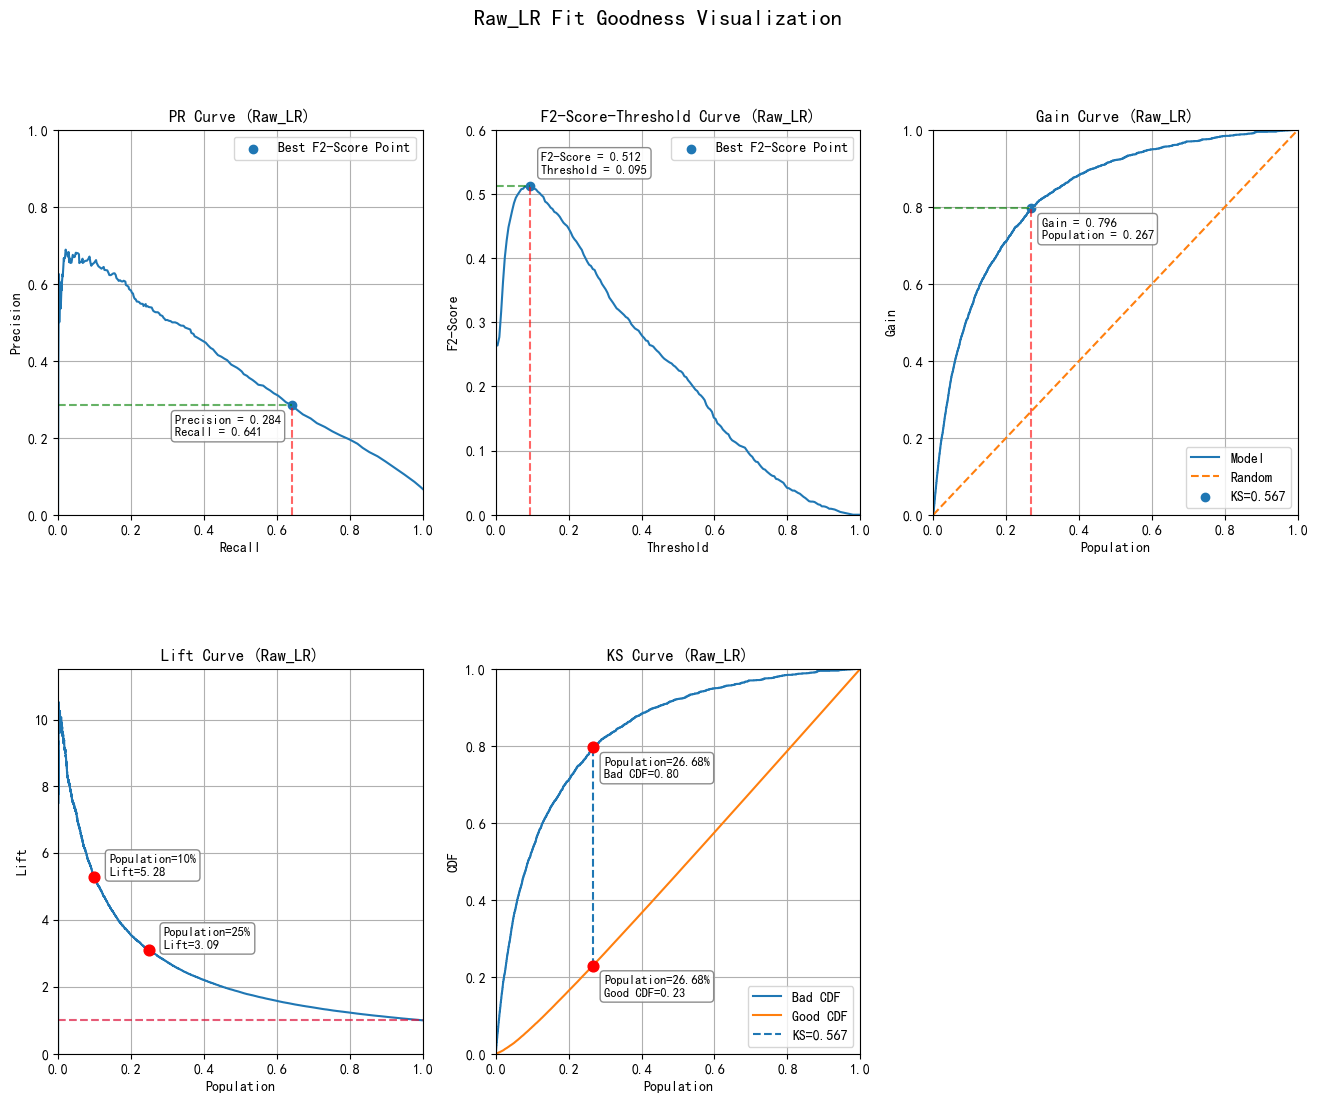

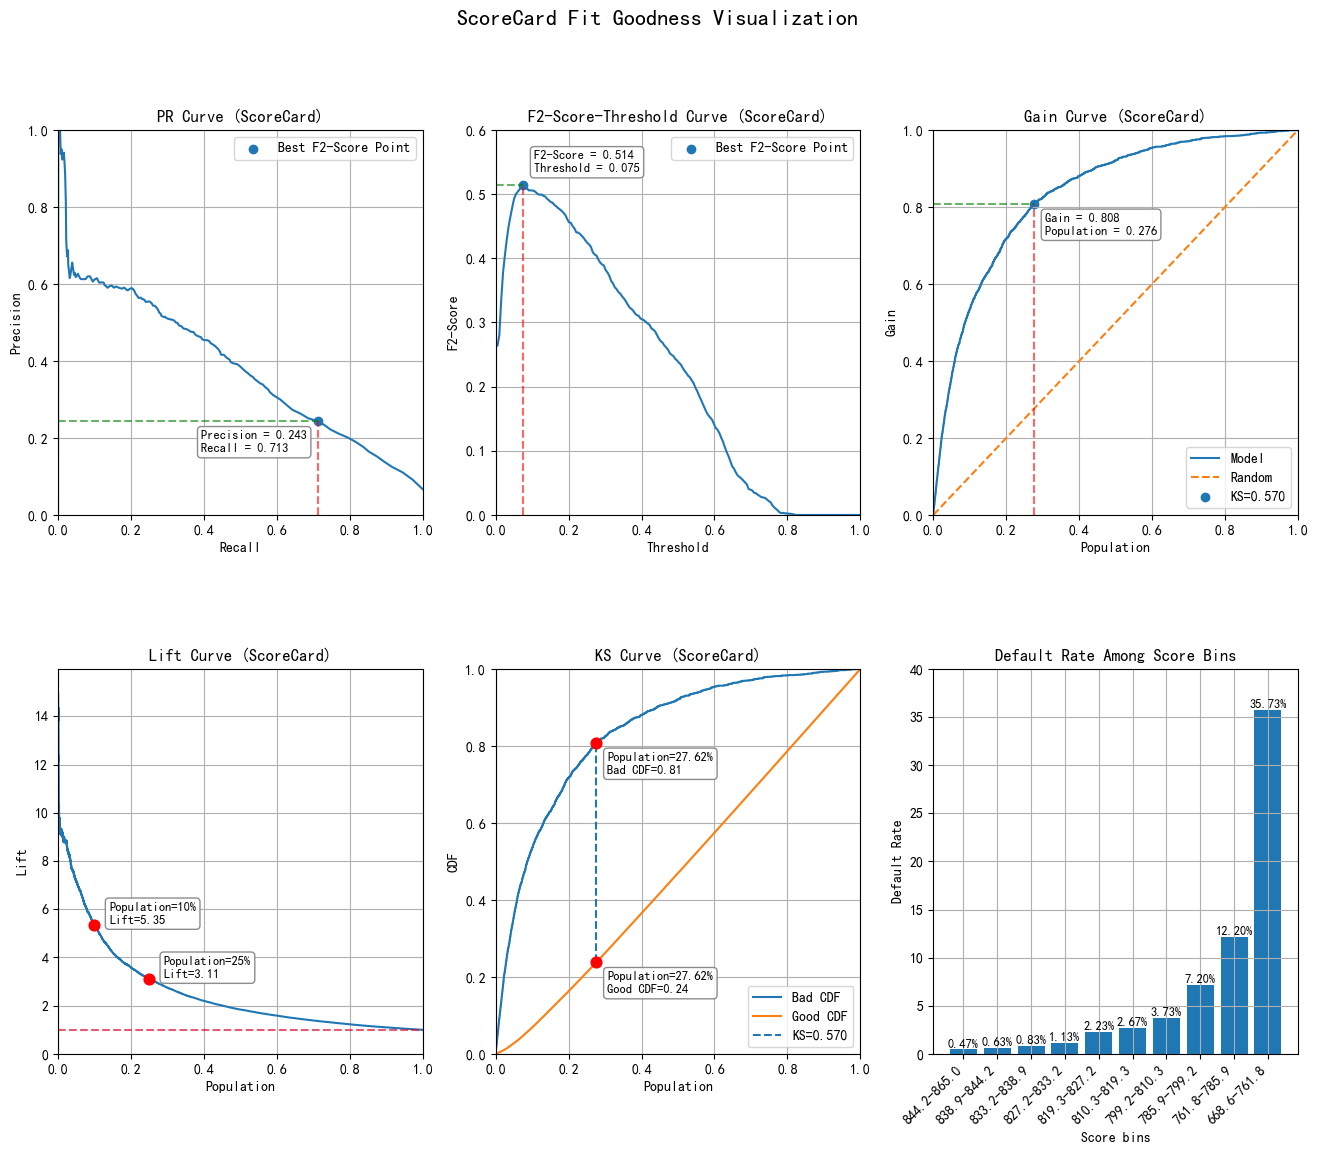

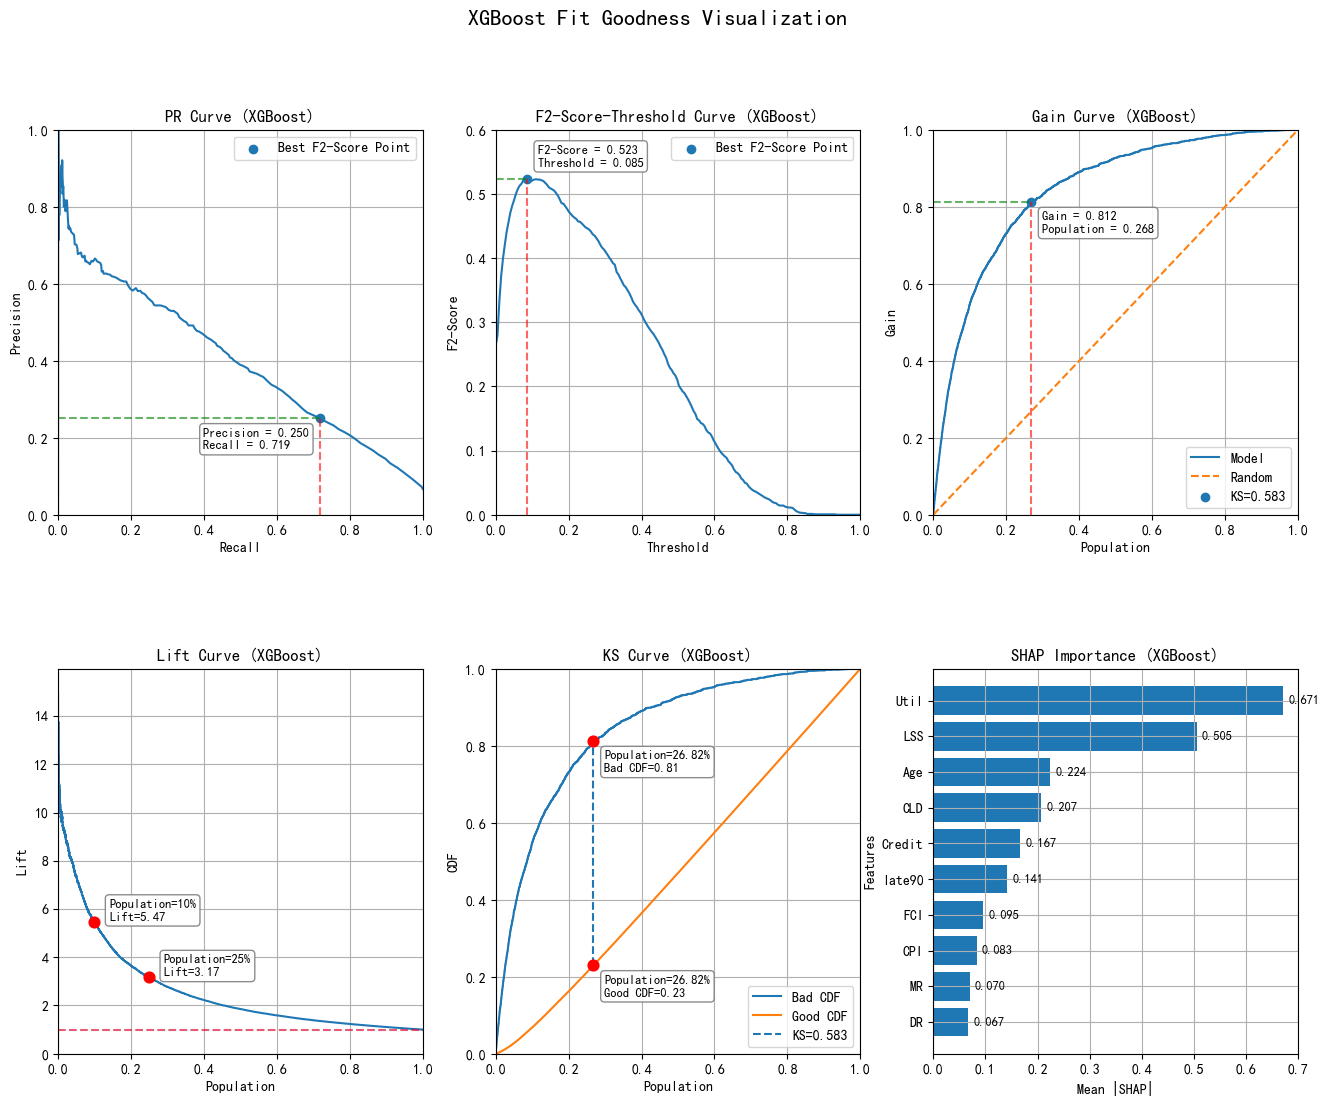

In [47]:
# 可视化地对比三种模型的拟合效果
if is_processing_here6:
    fig_list = visualize_fit_goodness(
        y_test, 
        X_test_raw_lr, X_test_woe_lr, X_test_xgb,
        raw_lr_model, sc_model, xgb_model
    )
    fig_list